## 1. Введение

<p style="border:3px black solid; text-align: left; padding: 10px">✍ Настало время поговорить о деревьях. Но не о тех, что растут в лесу, а об алгоритме машинного обучения под названием дерево решений (decision tree).

Саму модель дерева решений мы уже использовали, решая множество различных задач машинного обучения: от определения наличия диабета у пациента до предсказания длительности поездок на такси. Но задавались ли вы вопросом, как работает эта модель с точки зрения математики? Настало время это выяснить.

##  2. Деревья решений в контексте задач классификации и регрессии

<p style="border:3px black solid; text-align: left; padding: 10px">✍ С общими представлениями о модели дерева решений мы знакомились, когда изучали задачу классификации (ML-3. Обучение с учителем: классификация). Это неслучайно, ведь изначально деревья решений создавались именно для решения этой задачи. Чуть позднее оказалось, что алгоритм может быть запросто адаптирован и для решения задач регрессии.<br>
В этом модуле мы будем рассматривать деревья решений параллельно в контексте задач классификации и регрессии. Демонстрация работы алгоритма на обеих задачах позволит нам посмотреть на картину в целом и наглядно покажет сходства и различия моделей. Забегая вперёд, скажем, что алгоритмы построения дерева решений для задач классификации и регрессии отличаются лишь в паре шагов.<br>
Для начала мы посмотрим, что вообще представляет собой обученное дерево решений, и заодно закрепим «древесную» терминологию, с которой знакомились ранее, — она будет нас сопровождать на протяжении всего модуля.<br>
Так как мы находимся в разделе MATH&ML, то и говорить будем на строгом математическом языке, но при этом будем сопровождать свои рассуждения переводом на «человеческий».

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">У нас есть набор из 500 объектов, которые описываются пятью какими-то характеристиками. Например, это могут быть 500 пациентов, у которых измерили пять медицинских параметров: вес, рост, давление, количество лейкоцитов в крови и уровень сахара.<br>
В паре с объектом всегда идёт целевая переменная, которую необходимо научиться предсказывать. Например, целевой переменной может быть признак болезни: 1 — болен диабетом, 0 — не болен диабетом.<br>
Наша цель — построить модель машинного обучения, которая на основе характеристик объекта предсказывает целевую переменную. Для нашего примера это будет модель, которая на основе медицинских параметров выдаёт свой прогноз о наличии у пациента диабета.

Это была классическая постановка задачи машинного обучения в свободной форме. Давайте теперь посмотрим, как будет выглядеть та же самая задача на языке математики.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Далее для простоты изложения и упрощения обозначений мы не будем писать стрелки над векторами. Если какая-то переменная будет являться векторной, мы будем указывать на это в явном виде.В контексте разговора о деревьях нам будет удобнее использовать не чистый аппарат линейной алгебры, а совместить его с теорией множеств.

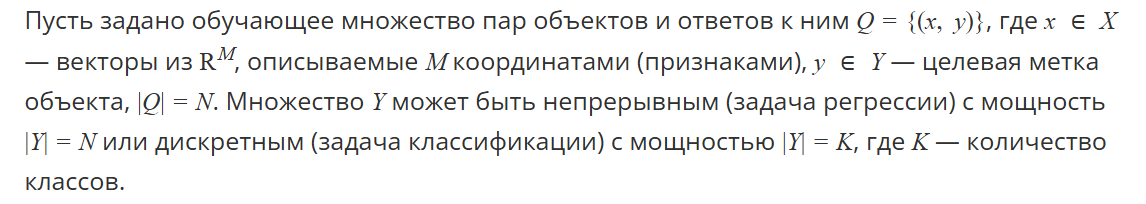

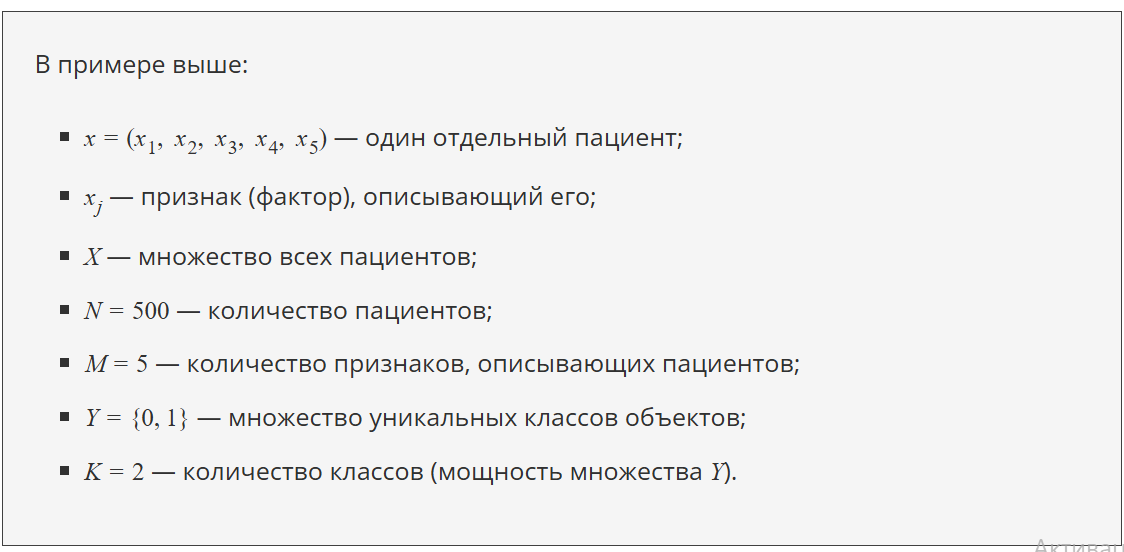

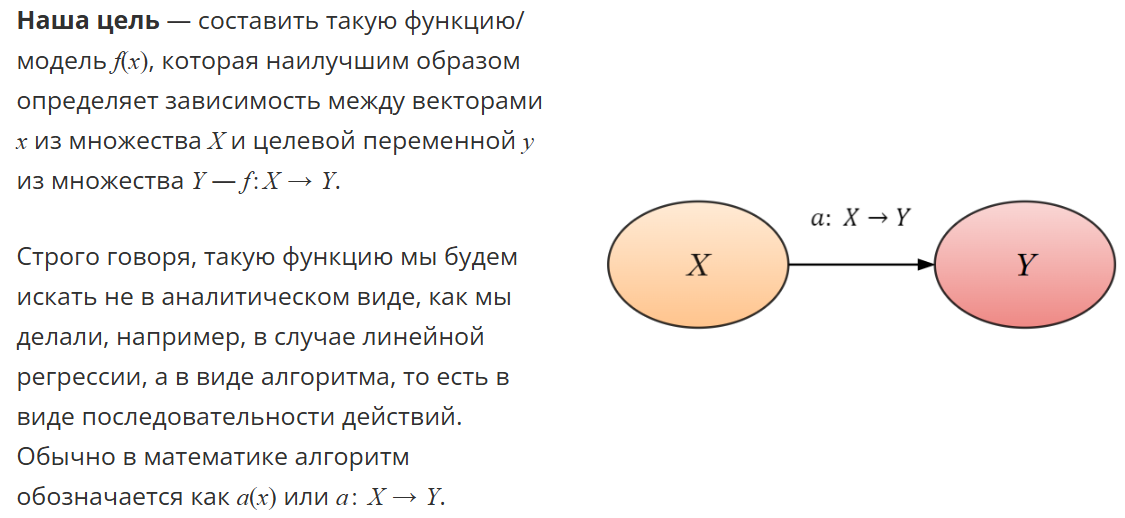

Алгоритм a(x) мы будем искать в семействе деревьев решений.

<center>$\color{green}{\text{ОПРЕДЕЛЕНИЕ РЕШАЮЩЕГО ДЕРЕВА}}$</center>

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px">Если говорить простыми словами, <b>обученное дерево решений</b> — это последовательность вопросов, которые задаются поступающим на его вход объектам.

Например:

- «Рост ≤ 170 см?» 
- «Вес ≤ 60 кг?»
- «Содержание сахара ≤ 70 мг/дл?»

В зависимости от того, выполняется ли заданное в вопросе условие, объект переходит к одному из следующих вопросов, и так происходит до тех пор, пока не будет получен конечный результат — прогноз дерева решений для данного объекта. Всё это очень напоминает стандартные рассуждения по принципу «если…, то».

В качестве примера дерева решений в текстовом виде приведём процесс принятия решения о том, куда поехать в отпуск.

- Если «бюджет ≤ 1000»:
 - Если «продолжительность отпуска ≤ пяти дней»:
   - Едем на дачу
 - Если «продолжительность отпуска > пяти дней»:
   - Едем в Кисловодск

- Если «бюджет > 1000 »:
 - Если «продолжительность отпуска ≤ десяти дней»:
   - Едем в Сочи
 - Если «продолжительность отпуска > десяти дней»:
   - Едем в Египет

Последовательность вопросов можно оформить в виде вершин графа, структура которого будет напоминать перевёрнутое дерево.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Пройдя путь, который зависит от характеристик объекта, через последовательность от первого вопроса (корня дерева) до финального ответа (листа) мы можем определить значение целевой переменной. В задаче регрессии финальный ответ дерева — некоторое число, а в задаче классификации — класс объекта.

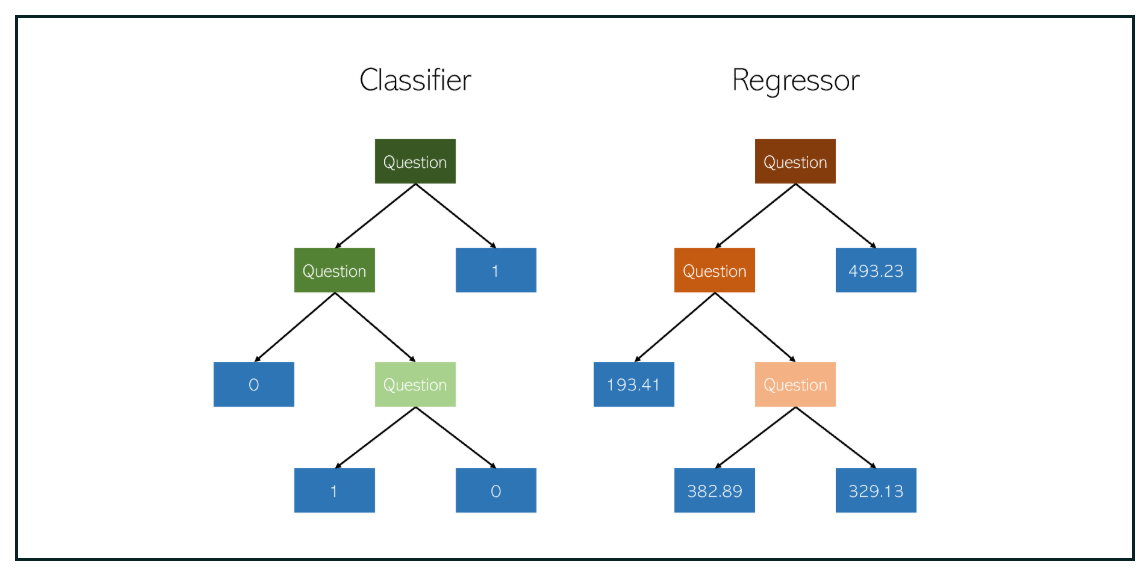

Давайте переведём вышесказанное на более формальный язык математики, на котором, собственно, и работает программная реализация дерева решений.

Дерево решений представляет собой последовательность условий вида $x_j≤t$, которые называются предикатами, или решающими правилами.

Формально сами предикаты в вершинах мы ранее обозначали как:

$$B_ν(x_j, t) = I[x_j≤t]$$

где $ν$ — номер вершины графа, а $I$ с квадратными скобками [] — обозначение индикаторной функции (она равна 1 (True), если условие внутри скобок выполняется, и 0 (False) — в противном случае).

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Примечание. Далее для удобства мы будем обозначать индикаторную функцию I простыми квадратными скобками, например:
$$Bν(x_j, t) = [x_j≤t]$$

Каждый предикат разделяет множество объектов X на два подмножества:

- левое — множество тех объектов, для которых заданное в предикате условие выполняется: $X^{left}={x | x_j≤t}$;
- правое — множество тех объектов, для которых условие ложно: $X^{right}=X∖Xleft={x∣x_j>t}$.

Последовательность предикатов лучше всего представлять в виде **ациклического связного графа**. 

Давайте посмотрим на пример такого графа для дерева решений глубиной 4. Дерево решает задачу классификации 15 наблюдений (мощность множества X) на три класса (мощность множества Y):

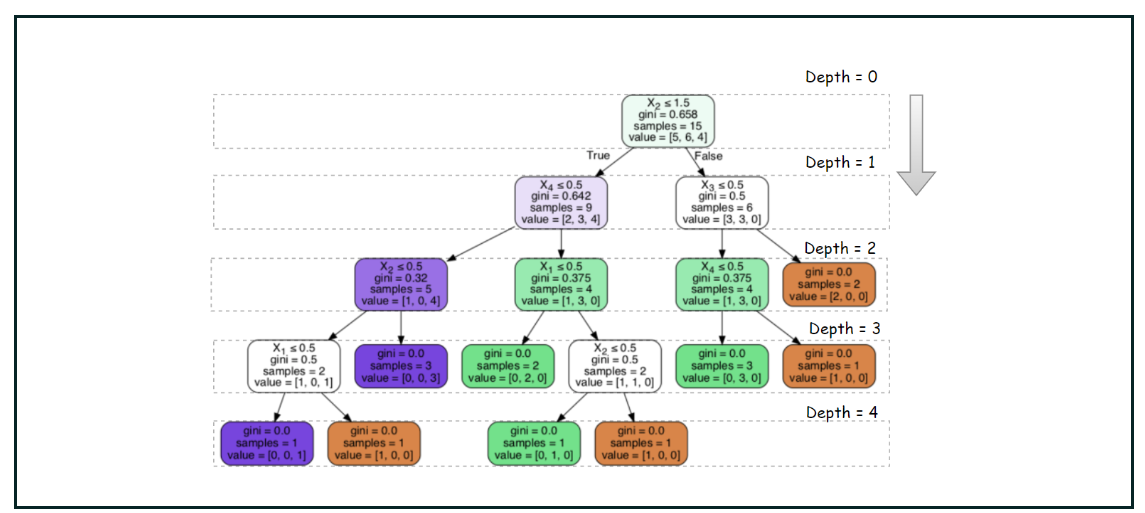

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Информация, указанная в вершинах графа, определяется во время обучения дерева решений, о процедуре которого мы поговорим в следующих юнитах:<br>
- $x_j≤t$ — условие предиката;
- gini — значение критерия информативности (в данном случае используется критерий Джини);<br>
- samples — число объектов из обучающей выборки, попавших в вершину;<br>
- value — число объектов каждого из классов из обучающей выборки, попавших в вершину.

В построенном графе выделяют **три типа вершин:**

- корневая вершина (root node) — то, откуда всё начинается;
- внутренние вершины (intermediate nodes);
- листья (leafs) — конечные вершины дерева, в которых определяется конечный «ответ» — прогноз дерева решений.

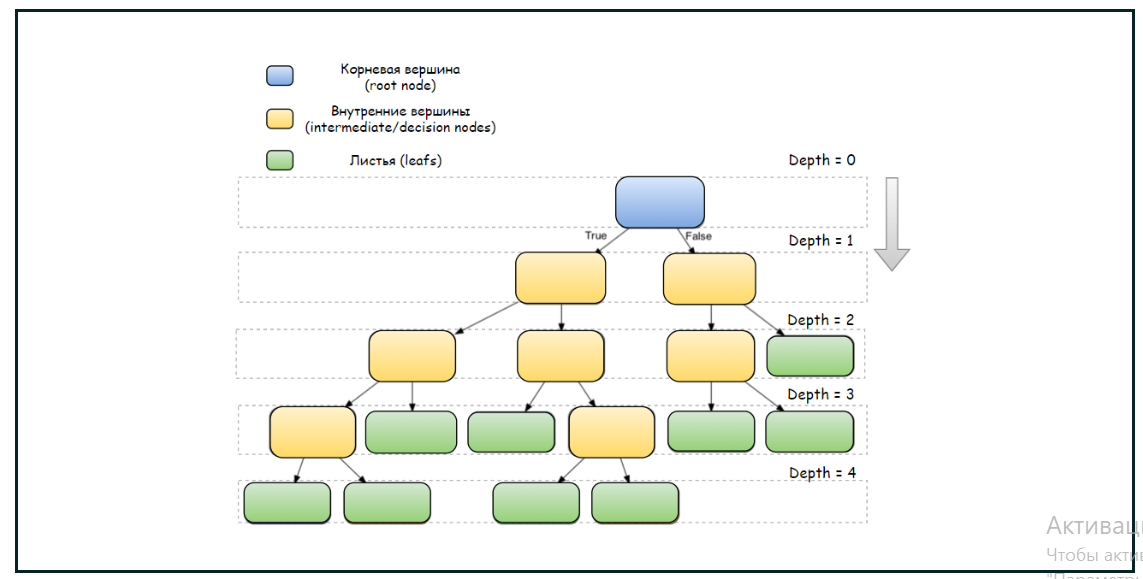

Вершины графа группируются в уровни, которые называются глубиной дерева (depth). Отсчёт уровней ведётся с 0 (то есть корневая вершина не считается при подсчёте глубины дерева).

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Корневая и внутренние вершины содержат предикаты $Bν(x_j, t)$, на основе которых организуется движение по графу. В ходе предсказания осуществляется проход по дереву к некоторому листу. Для каждого объекта из выборки движение начинается из корня.

В вершине v проход осуществляется влево, если для объекта x условие, записанное в предикате, выполняется, то есть$B_ν(x_j, t)=1$, и вправо, если условие является для объекта x ложным, то есть $B_ν(x_j, t)=0$. Проход продолжается до момента, пока будет достигнут некоторый лист. Ответом алгоритма для объекта x считается прогноз  ˆy =a(x), приписанный этому листу.

В задаче **регрессии** прогноз целевой переменной ˆy будет определяться принципом усреднения, то есть объекту x в качестве прогноза присваивается среднее (или медианное) значение целевой переменной по объектам, попавшим в лист на этапе обучения дерева.

В задаче **классификации** прогноз целевой переменной ˆy будет определяться принципом голосования большинства, то есть объекту x присваивается самый популярный класс объектов, попавших в лист на этапе обучения дерева.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px"><span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Пусть появился новый объект x. Ещё раз напомним, что под переменной x может скрываться всё что угодно: пациент, автомобиль, клиент банка и т. д.<br>
Этот объект представляется в виде четырёхмерного вектора-строки. Пусть он будет иметь следующий вид:
$$x=(x_1, x_2, x_3, x_4)=(1, 1, 1, 0)$$
Каждая координата вектора x — это некоторая характеристика объекта, например, вес, рост, давление и т. д.<br>
Необходимо определить прогноз дерева решений — класс объекта ˆy=a(x). Классы обозначены метками от 0 до 2.

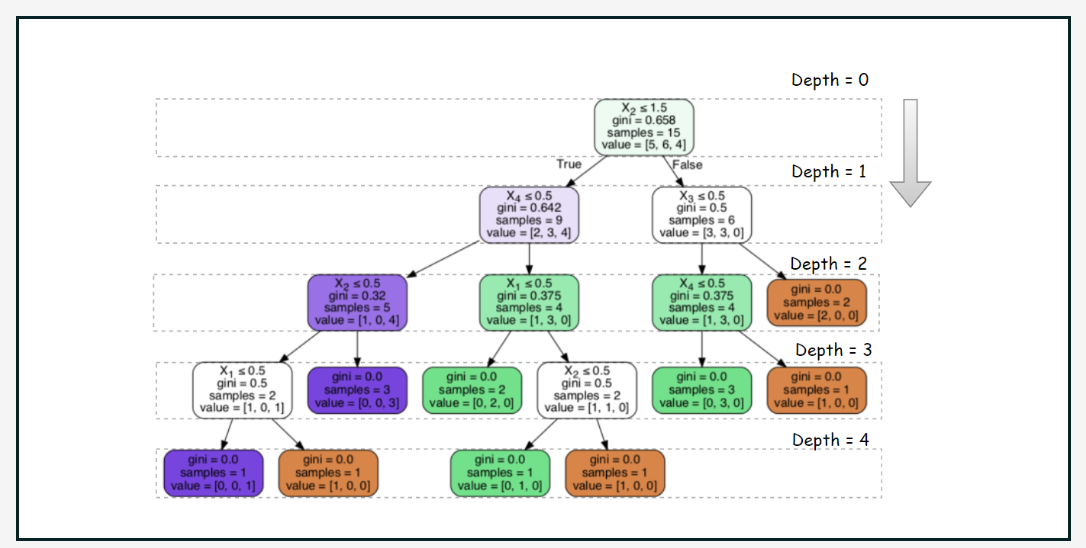

Номер вершины v будем определять в формате ij, где i — глубина дерева, а j — номер вершины на i-й глубине слева-направо (если таких вершин несколько). Номер корневой вершины традиционно обозначается за v=0.

Смотрим на первую (корневую) вершину нашего графа. В ней записан предикат:

$$B_0(x_j=x_2, t=1.5)=[x_2≤1.5]$$

Определяем значение предиката $B_0$ для нашего объекта x:

$$B_0=[x_2≤1.5]=[1≤1.5]=1$$

Так как $B_0=1$, то мы переходим из этой вершины в левую ветвь дерева — в вершину под номером v=11.

Предикат в следующей вершине (B11) имеет вид:

$$B_{11}(x_j=x4, t=0.5)=[x_4≤0.5]$$

Определяем значение предиката B11 для нашего объекта x:

$$B_{11}=[x_4≤0.5]=[0≤0.5]=1$$

Так как $B_{11}=1$, то мы снова переходим из этой вершины в левую ветвь дерева — в вершину под номером v=21.

Предикат в следующей вершине (B21) имеет вид:

$$B_{21}(x_j=x2, t=0.5)=[x_2≤0.5]$$

Определяем значение предиката $B_{21}$ для нашего объекта x:

$$B_{21}=[x2≤0.5]=[1≤0.5]=0$$

Так как $B_{21}=0$, то мы переходим из этой вершины в правую ветвь дерева — в вершину под номером $v=32$.

Вершина дерева под номером $v=32$ не содержит предиката, так как является листовой. Она содержит информацию о количестве объектов каждого из классов в обучающей выборке (список value): $[0, 0, 3]$. То есть при обучении дерева в вершину под номером $v=32$ попало по 0 объектов классов «0» и «1» и три объекта класса «2».

Можно визуализировать наш путь по графу:

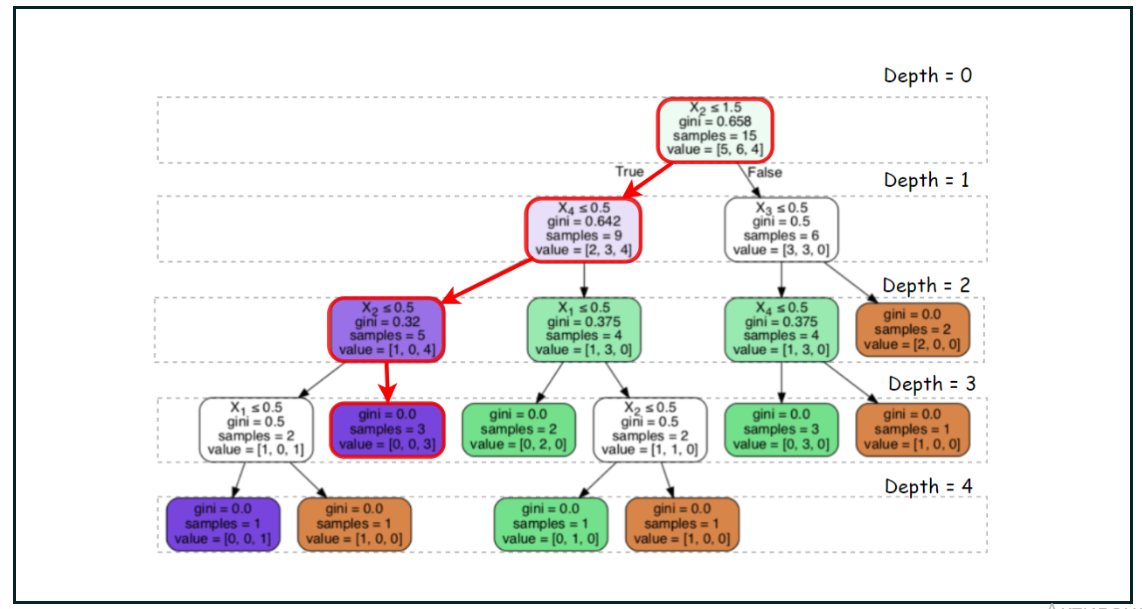

Класс объекта будет определён как наиболее популярный в конечной вершине, то есть:

$$\hat{y}=a(x)=argmax([0,\ 0,\ 3])=2$$

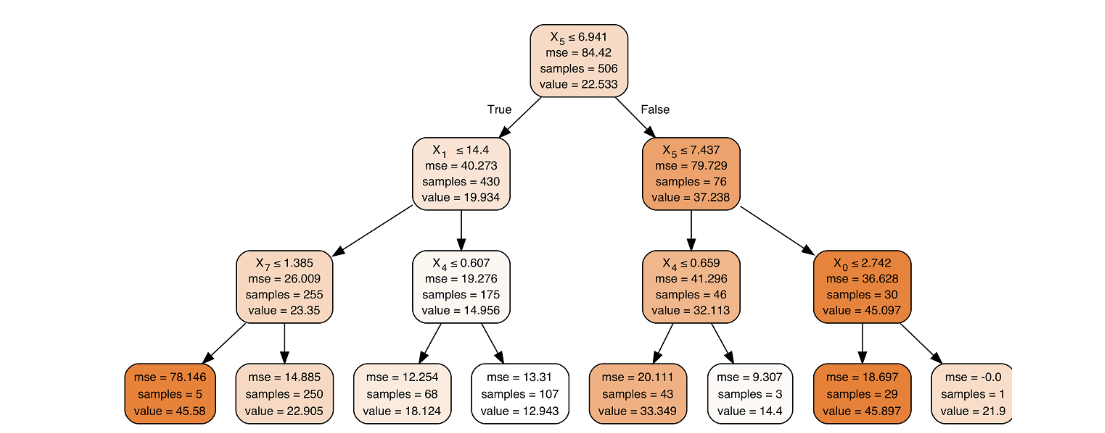

На основе построенного графа дерева сделайте предсказание целевой переменной (в вершинах оно записано как value) для нового объекта $x$, если:

$$x=(3,\ 14,\ 0,\ 12,0.8,\ 5.3,0,\ 1.4)\$$

<center>$\color{green}{\text{ГЕОМЕТРИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ ДЕРЕВА РЕШЕНИЙ}}$</center>

Геометрически каждый предикат $B_v(x_j,\ t)=[x_j\le t]$ задаёт в пространстве факторов разделяющую плоскость. Эта плоскость всегда будет перпендикулярна оси фактора $x_j$ и будет делить пространство факторов на две части: ту, для которой условие $x_j\le t_4$ выполняется, и ту, для которой это условие ложно. 

Следующие предикаты будут делить каждую из образованных при прошлом разделении областей на две другие части и так далее, пока не будут образованы листовые вершины.

В результате построения дерева решений мы получаем пространство факторов, разделённое на $l$ областей, каждая из которых соответствует своей листовой вершине. Обозначим эти области как $R_p, p=1,\ 2,...,\ l$

В случае, когда фактор всего один, то есть объект $x\in \ X$ является одномерным вектором из пространства действительных чисел $\mathbb{R}$, вся числовая ось фактора $x_1$ разбивается на отрезки. Пример такого случая представлен ниже:

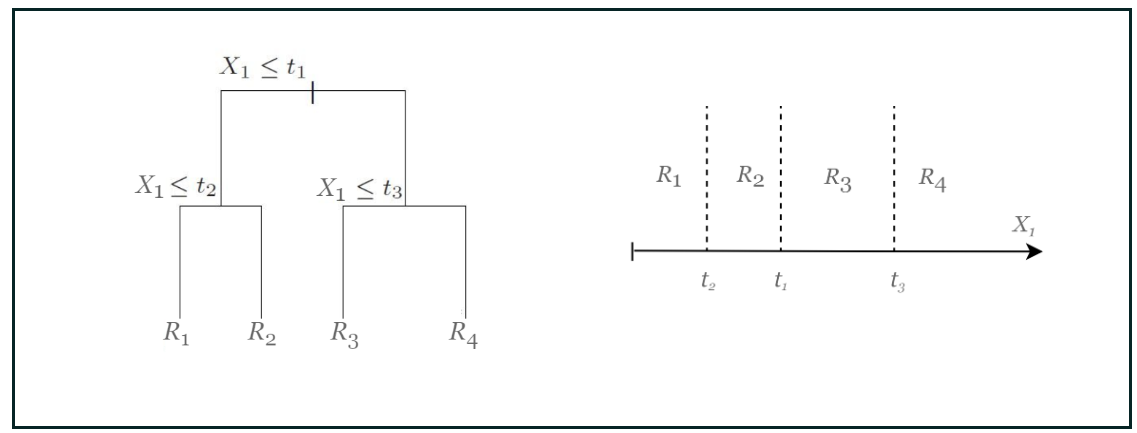

В случае, когда факторов только **два**, то есть объект $x\in \ X$ является двухмерным вектором из пространства $\mathbb{R}^2$, всё пространство факторов будет разбито на прямоугольные области. Пример такого случая представлен ниже:

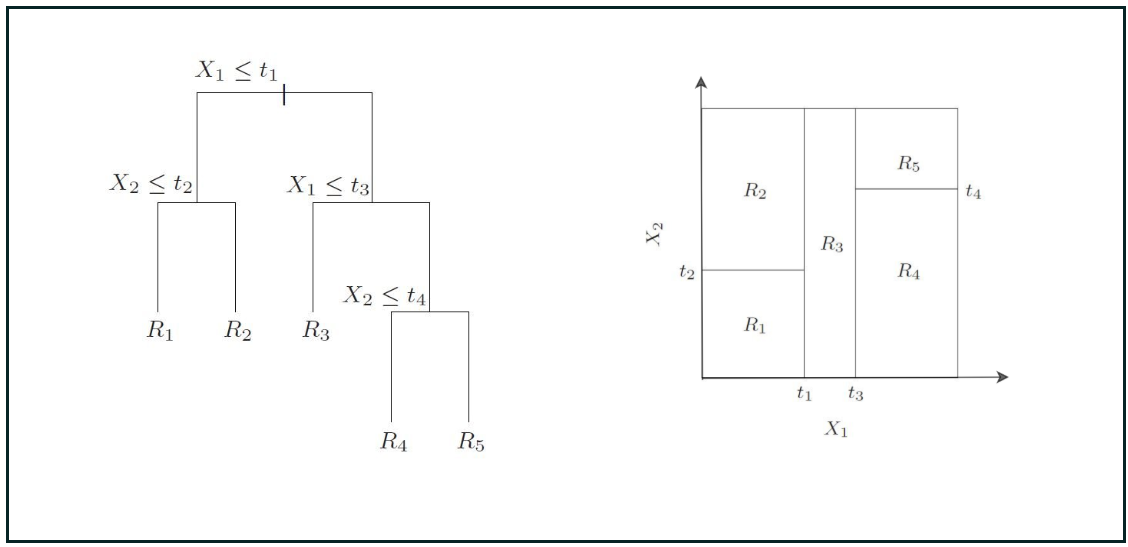

В случае, когда в нашем распоряжении есть три фактора, то есть объект $x\in \ X$ является трёхмерным вектором из пространства $\mathbb{R}^3$, мы получаем трёхмерное пространство, разделённое на параллелепипеды. Пример:

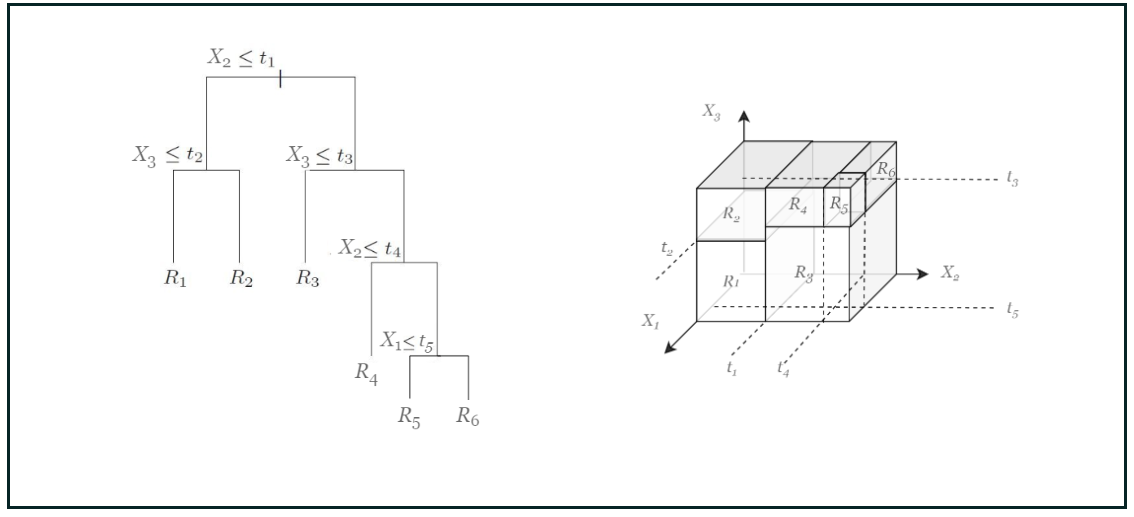

В общем случае, когда факторов $m$ штук, то есть объект  является вектором из пространства $x\in \ X$, мы получаем $m$-мерное пространство, разбитое на области, представляющие собой -мерные параллелепипеды или, как их называют в математике, гиперпараллелепипеды.

В случае **задачи регрессии (Decision Tree Regressor)** ответ модели (значение целевого признака) будет определяться как среднее значение целевой переменной $y$ внутри области $R_p$, соответствующей листовой вершине. Математически это записывается следующим образом: $$\hat{y}=a(x)=\frac{1}{\left|R_p \right|}\sum_{y \ \in \ R_p}{}y$$

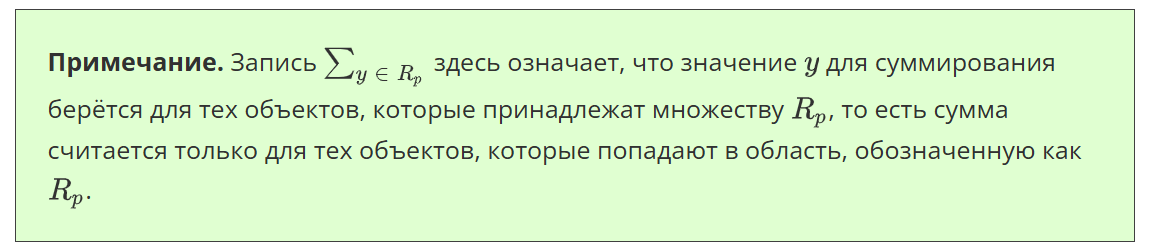

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Воспользуемся данными о недвижимости в штате [Айова из Ames Housing Dataset](https://www.kaggle.com/datasets/prevek18/ames-housing-dataset). Это классическая задача предсказания цены недвижимости, которую мы уже решали не раз с различными датасетами.

Для примера визуализации из всех признаков, описывающих объекты недвижимости, мы выберем:

- Lot_Frontage — ширина фасада;
- Lot_Area — площадь объекта недвижимости.

Необходимо предсказать стоимость недвижимости (*Sale_Price*). Файл с данными вы можете скачать здесь.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree

Как обычно, подготовим обучающую выборку, отделив факторы $X$ и целевую переменную $y$:

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Для более понятной визуализации перед построением дерева уберём из датасета объекты с Lot_Frontage > 150 и с Lot_Area > 20000.

In [2]:
# Создаём обучающую выборку
ames_data = pd.read_csv('data/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
X = ames_data[['Lot Frontage', 'Lot Area']]
y = ames_data['SalePrice']

Создадим модель дерева решений для задачи регрессии с максимальной глубиной 3 и обучим её. Напомним, что в sklearn за реализацию дерева решений для задачи регрессии отвечает класс [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) из модуля tree.

In [3]:
# Инициализируем модель дерева решений с максимальной глубиной 3 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=3)
dt_reg.fit(X.values, y)

DecisionTreeRegressor(max_depth=3)

Отследить, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений. Напомним, что за его визуализацию в библиотеке sklearn отвечает функция [plot_tree()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) из модуля tree.

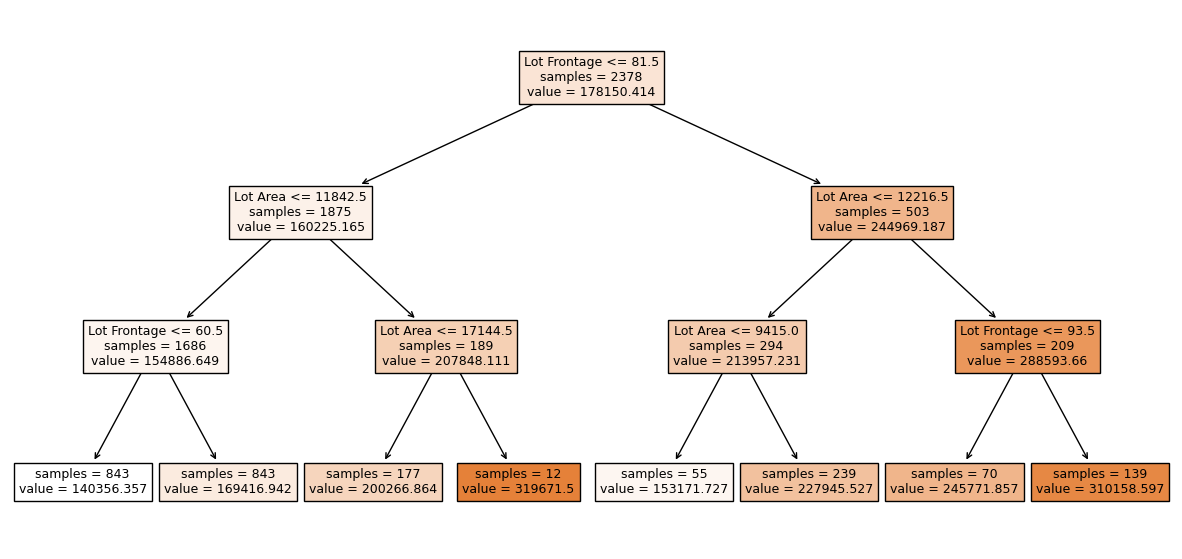

In [4]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию *plot_decision_bound_regression()*:

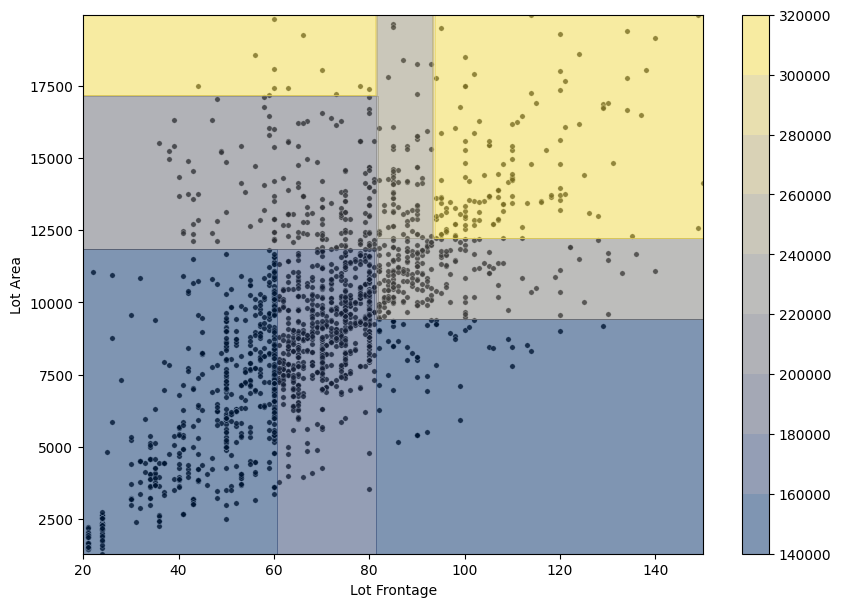

In [5]:
def plot_decision_bound_regression(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    y_pred = model.predict(X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_regression(X, y, dt_reg, fig)

Что мы здесь видим? В результате построения дерева решений было образовано восемь областей ($R_1, R_2,..., R_8$), соответствующих каждому из восьми листьев. В каждой из областей было рассчитано предсказание дерева для этой области $y$ — среднее арифметическое целевой переменной  (они отражены на тепловой шкале справа от диаграммы) по формуле, приведённой выше.

Прогноз для нового объекта будет определяться в зависимости от того, в какую из полученных областей он попадёт.

**В случае задачи классификации (Decision Tree Classifier)** ответ модели (класс объекта) будет определяться голосованием большинства внутри области $R_p$, то есть дерево будет возвращать тот класс, который наиболее популярен в области $R_p$, соответствующей листовой вершине.

Как записать это в виде формулы? Необходимо вычислить оценку вероятности принадлежности объекта к каждому из классов $p_k$.

Формула оценки вероятности принадлежности объекта к $k$-му классу будет иметь следующий вид:

$$P_k=\frac{1}{\left|R_p \right|}\sum_{y\ \in \ R_p}{}[y=k]$$,

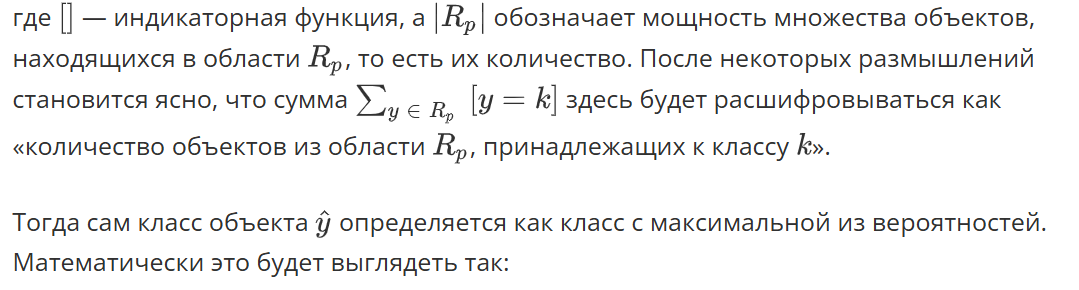

$$\hat{y}=a(x)=argmax_{k\in K}(P_k)$$

Давайте посмотрим на пример разделяющей поверхности дерева решений в случае задачи классификации ↓

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Воспользуемся данными о банкнотах из [Banknote Authentication Dataset](https://archive.ics.uci.edu/ml/datasets/banknote+authentication). В качестве примера для визуализации из всех характеристик, описывающих изображения банкнот, будем использовать:

- Variance (дисперсию);
- Skewness (асимметрию).

Наша цель — предсказать, является ли банкнота фальшивой (Class): 1 — фальшивая, 0 — подлинная. 

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Данные были получены из изображений, которые соответствуют подлинным и поддельным образцам банкнот. Для оцифровки использовалась промышленная камера, обычно используемая для проверки отпечатков. Конечные изображения имеют размер 400x400 пикселей. <br>
Далее эти изображения были подвергнуты специальному <b>вейвлет-преобразованию</b>. Это преобразование, которое позволяет закодировать изображение в виде набора чисел. Если вам интересно подробнее изучить эту тему, рекомендуем прочесть данную статью(https://habr.com/ru/post/168517/).<br>
Из преобразованных данных были извлечены различные статистические характеристики.

In [6]:
# Создаём обучающую выборку    
bill_data = pd.read_csv('data/bill_authentication.csv')
X = bill_data[['Variance', 'Skewness']]
y = bill_data['Class']

Создадим модель дерева решений для задачи классификации (класс [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) из модуля tree библиотеки sklearn) с максимальной глубиной 4 и обучим её.

In [7]:
# Инициализируем модель дерева решений с максимальной глубиной 4 и обучаем её
dt_clf = tree.DecisionTreeClassifier(max_depth=4)
dt_clf.fit(X.values, y)

DecisionTreeClassifier(max_depth=4)

Отследить то, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений:

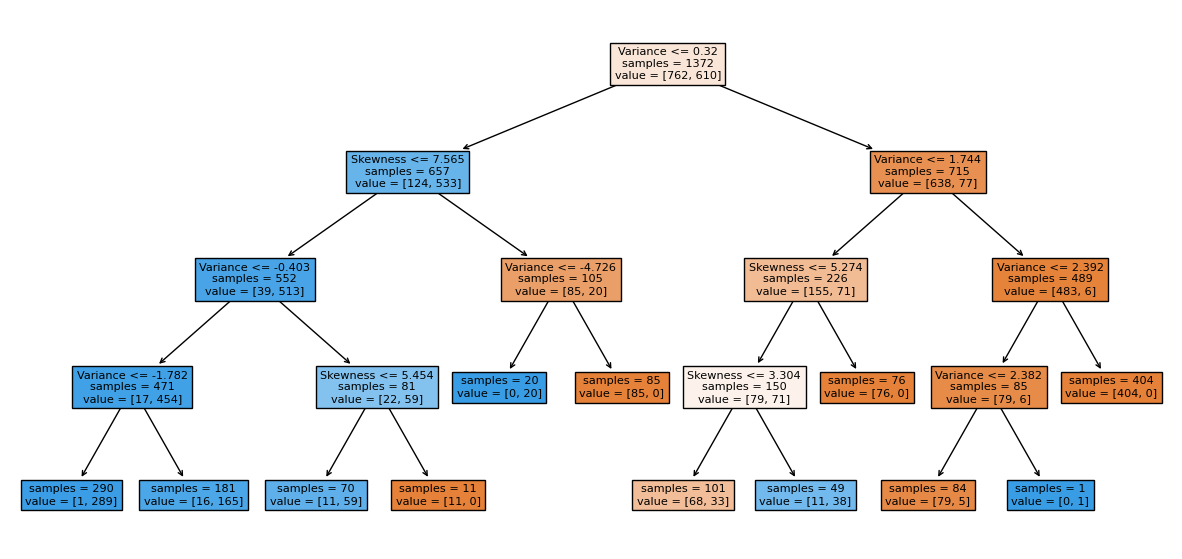

In [8]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_clf, #дерево решений
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

В результате построения дерева было образовано 12 областей ($R_1, R_2,..., R_{12}$), каждая из которых соответствует одному из 12 листьев. В каждой из областей была рассчитана оценка вероятности принадлежности к каждому из классов — $P_k$. Класс объекта $\hat{y}$ определяется как класс с максимальной из этих вероятностей.

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию *plot_decision_bound_classification()*:

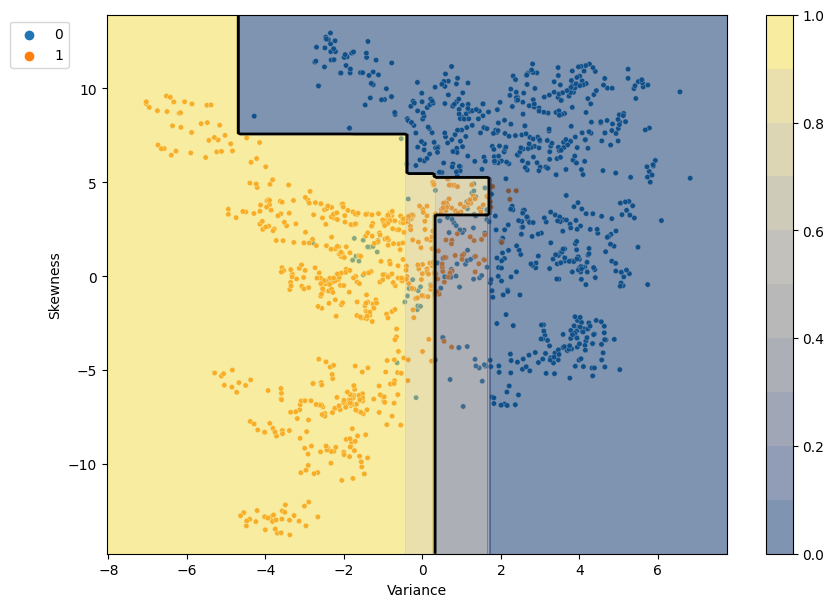

In [9]:
def plot_decision_bound_classification(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    probs = model.predict_proba(X_net)[:, 1]
    probs = probs.reshape(xx1.shape)
    
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, s=15, alpha=1)
    contour = plt.contourf(xx1, xx2, probs, 10, cmap='cividis', alpha=0.5)
    bound = plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    fig.colorbar(contour)
    plt.legend(bbox_to_anchor=(-0.05, 1))
# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_classification(X, y, dt_clf, fig)

Выше представлена тепловая карта вероятностей принадлежности к классу фальшивых банкнот — $\hat{P_1}$ (они отражены на тепловой шкале справа от диаграммы — области, для которых вероятности закрашены одинаковым цветом). Банкноты, для которых данная вероятность , дерево считает фальшивыми, а остальные $P_1>0.5$— подлинными.

В заключение по геометрии давайте посмотрим на пример того, как будет выглядеть геометрическая интерпретация прогноза дерева решений в случае построении регрессии целевой переменной $y$ в зависимости только от одного фактора $x_1$.

На графиках ниже представлены предсказания модели дерева решений $\hat{y}$ с различной глубиной. Для примера зависимости $y$ от $x_1$ возьмём параболу с добавленным в неё случайным шумом $\varepsilon$:

$$y={x^2}_1+\varepsilon$$

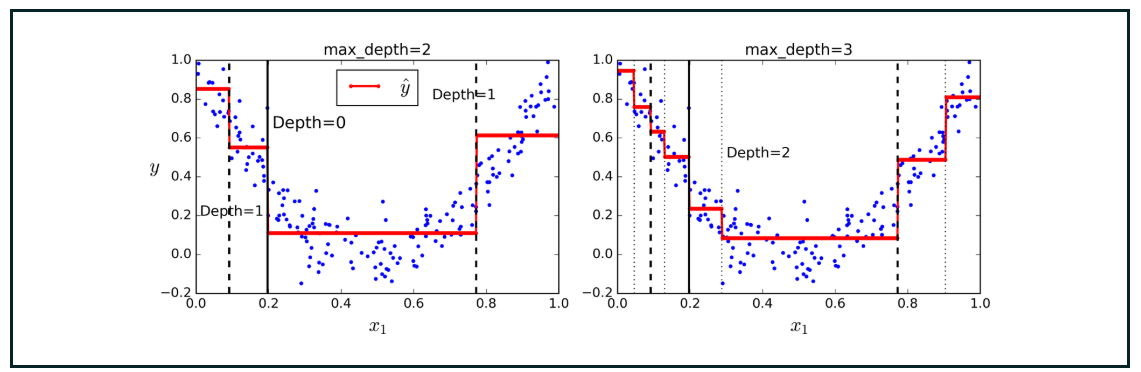

Видно, что прогнозом дерева $\hat{y}$ будет ступенчатая кусочно-постоянная функция. Каждая ступенька — это среднее значение целевой переменной $y$ на участке, соответствующем листовой вершине дерева. Легко понять, что чем больше глубина дерева, тем больше в нём листьев, а значит будет больше участков и прогноз на обучающей выборке с помощью среднего будет получаться точнее, что видно на графике справа. 

<center>$\color{green}{\text{СВОЙСТВА АЛГОРИТМА ДЕРЕВА РЕШЕНИЙ}}$</center>

Подведём промежуточный итог. В начале юнита мы обозначили нашу глобальную цель — найти такую функцию $a(x)$, которая связывает два множества $X$ (множество объектов) и $Y$ (множество примеров).

Задав структуру дерева решений, а также решающие правила $B_v(x_j,\ t)$ в каждой из вершин, мы решим нашу задачу. Полученное дерево как раз и станет нашей функцией $a(x)$.

Да, дерево решений — это не классическая для нас аналитическая функция, как $x^2$ или $e^x$, к которым мы привыкли, решая задачи в модулях по математическому анализу. Это отдельный вид функций, представленных в виде последовательности действий — алгоритма.

Схематично связь между множествами $X$ и $Y$ можно представить следующим образом:

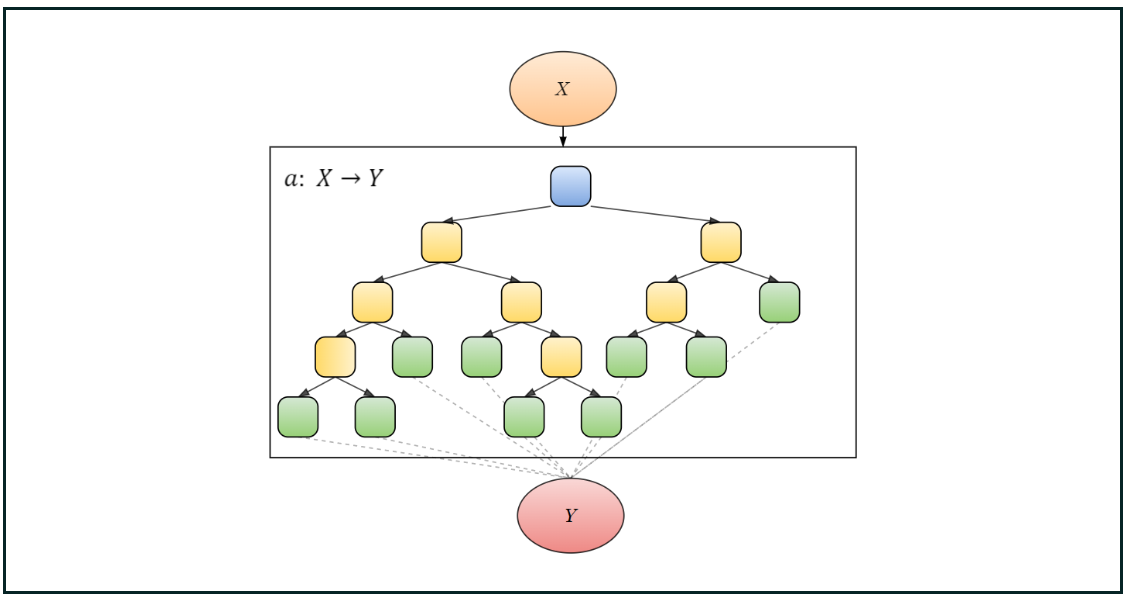

Из структуры дерева решений следует **несколько интересных свойств**:

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>Полученная функция $a(x)$ является кусочно-постоянной, а у таких функций производная равна нулю во всех точках, где задана функция. Следовательно, при поиске оптимального решения можно забыть о градиентных методах, таких как SGD.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>В случае задачи регрессии дерево решений (в отличие от, например, линейной регрессии) не может предсказывать значения целевой переменной за границами области значений обучающей выборки (на самом деле может, но для этого нужны специальные манипуляции над данными, которые не входят в рамки данного модуля).

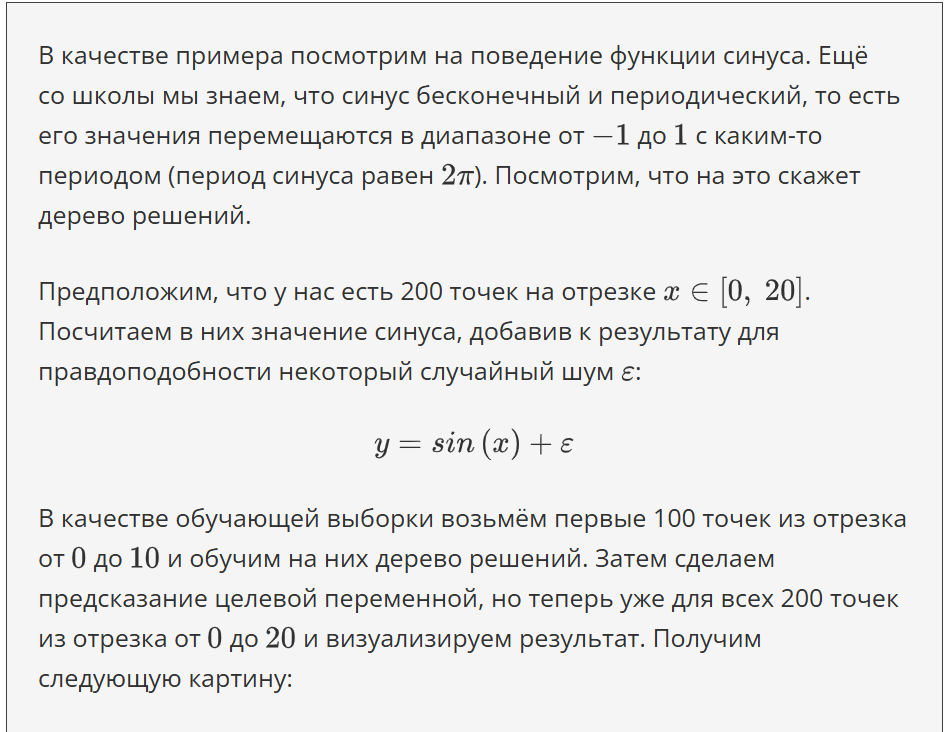

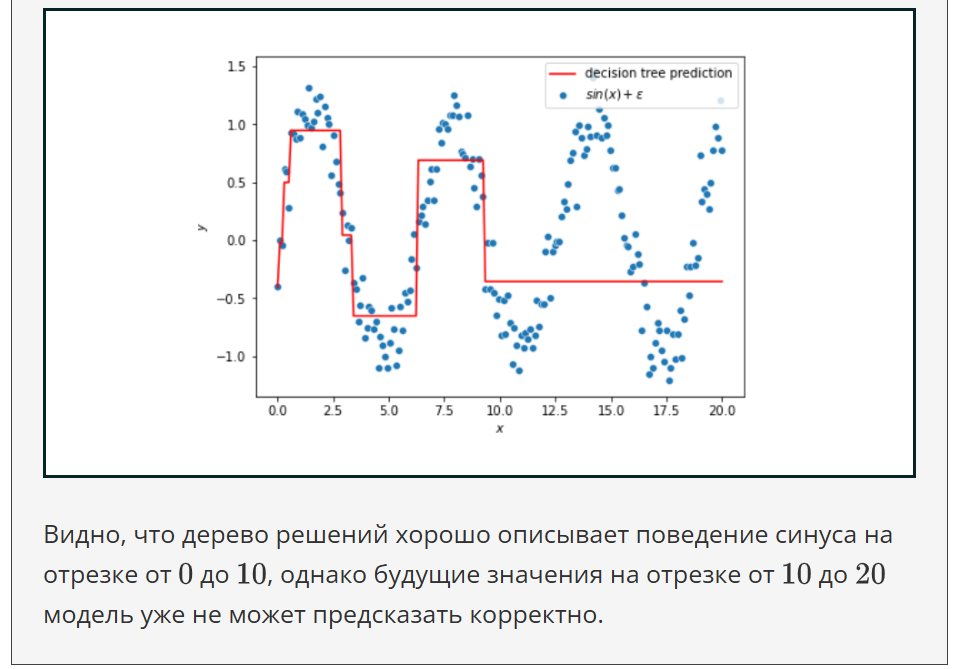

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>Дерево решений способно идеально приблизить обучающую выборку, но при этом ничего не выучить: для этого достаточно построить такое дерево, в каждый лист которого будет попадать только один объект.<br>
Такая модель будет обладать идеальным качеством на обучающей выборке, однако при её использовании на реальных данных качество будет низким. Иначе говоря, модель будет переобученной.

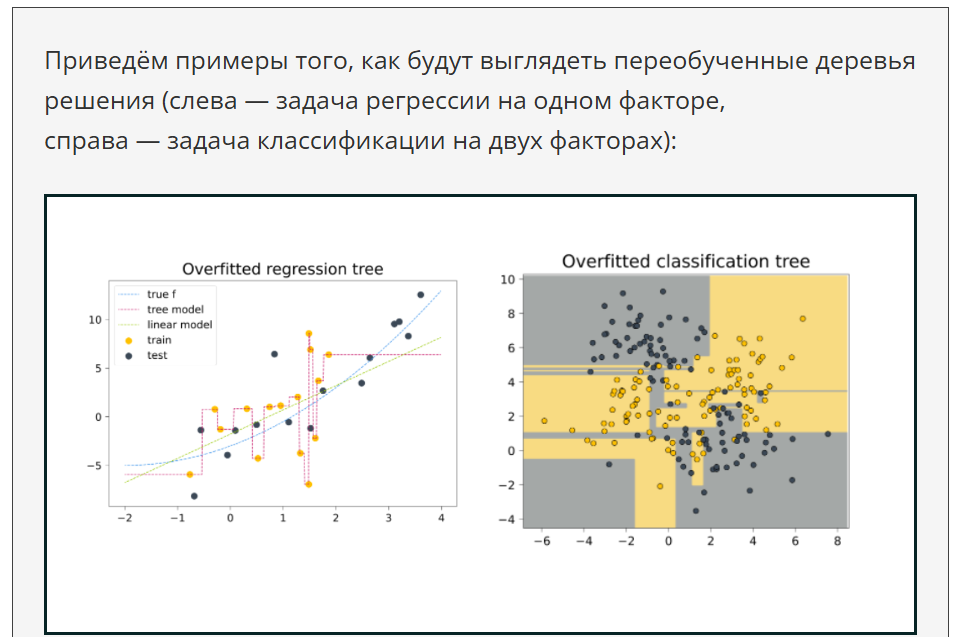

<div style="display: flex; justify-content: center; margin-bottom: 0;">
<div style="width: 45%;">
<p>В задаче<strong> регрессии</strong> мы выделили для каждого наблюдения из обучающей выборки (жёлтые точки на графике) свои отдельные листья. В результате мы получили очень сложную ступенчатую функцию, проходящую через каждую жёлтую точку. Однако эта функция совершенно не отражает общей зависимости и значение ошибки прогноза этой модели на тестовых данных (чёрные точки) будет гораздо выше.</p>
</div>
<div class="vert-line-blue-green"></div>
<div style="width: 45%;">
<p>В задаче<strong> классификации</strong> мы разделили пространство факторов так, что в каждую из областей попали объекты только одного класса. Эти прямоугольные области получились очень сложными и опять же не отражающими общей зависимости.</p>
</div>
</div>

##  3. Алгоритм CART: параметры разбиени

<center>$\color{green}{\text{МЕТОДЫ ПОСТРОЕНИЯ ДЕРЕВА РЕШЕНИЙ. АЛГОРИТМ CART}}$</center>

Существует несколько стратегий построения деревьев решений, но для нас будет представлять интерес только одна из них — алгоритм **CART**. Для особо любознательных мы собрали краткий список основных стратегий и указали их основные отличия друг от друга.

- [ID3](https://en.wikipedia.org/wiki/ID3_algorithm) (Iterative Dichotomiser 3) был разработан Джоном Куинланом (как и два последующих алгоритма) в 1986 году. Алгоритм создаёт многостороннее дерево, находя для каждого узла категориальный признак, который даст наибольший информационный выигрыш. Деревья вырастают до максимального размера, а затем обычно применяется этап обрезки, чтобы улучшить обобщающую способность деревьев и избежать переобучения.
 - Ограничения алгоритма:
   - все факторы должны быть категориальными;
   - предназначен для решения задач классификации.
- [C4.5](https://ru.wikipedia.org/wiki/C4.5) — алгоритм-преемник ID3. Он снимает ограничение, что факторы обязательно должны быть категориальными, путём разбиения непрерывного числового фактора на дискретный набор интервалов. C4.5 преобразует обученные деревья в наборы правил «если, ... то». Затем оценивается точность каждого правила, чтобы определить порядок, в котором они должны применяться.
- [C5.0](https://www.ibm.com/docs/es/spss-modeler/18.0.0?topic=trees-c50-node) — последняя лицензированная версия алгоритма. C5.0 использует меньше памяти и создаёт меньшие наборы правил, чем C4.5, но при этом является более точным.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px"><b>CART (Classification and Regression Tree)</b> — это алгоритм, предназначенный для построения бинарных деревьев решений. Он очень похож на C4.5, однако, в отличие от последнего, предназначен как для задач классификации, так и для задач регрессии. CART важен для нас, поскольку именно он используется для построения моделей решающих деревьев в sklearn.

Далее мы увидим, что CART строит деревья, используя факторы и пороговые значения, которые дают наилучшее уменьшение неоднородности (неопределённости) или, иначе говоря, наибольший прирост информации в каждой вершине дерева.

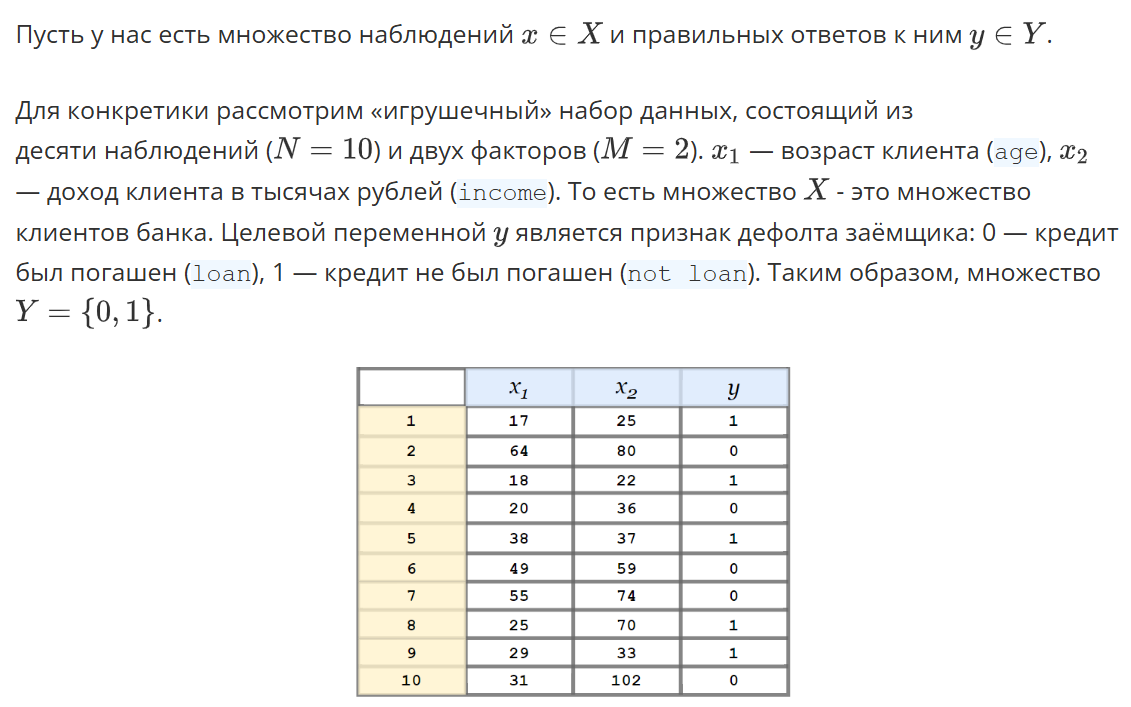

Нам необходимо построить алгоритм $a(x)$ — дерево решений, которое для клиентов из множества $X$ выдаёт ответ из множества $Y$ (выплатит ли заёмщик кредит).

По опыту работы с линейной регрессией мы знаем, что у моделей всегда есть внутренние параметры, которые мы пытаемся оптимизировать так, чтобы ошибка между ответами и предсказаниями на обучающей выборке была наименьшей. Обозначим эти параметры буквой $w$. 

Для начала разберёмся, что является внутренними параметрами дерева.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px">Под <b>внутренними параметрами</b> $w$ понимается структура дерева, а именно последовательность предикатов  $B_v(x_j,\ t)=[x_j\le t]$ и сами параметры $j$ (номер признака, по которому строится условие в предикате) и $t$ (пороговое значение для условия), то есть $w=(j,\ t)$. 

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Как мы уже заметили ранее, оптимизировать структуру дерева с помощью знакомых нам численных методов оптимизации, таких как SGD, не получится. Но как же тогда решить эту задачу? Как подобрать последовательность вопросов внутри вершин дерева?

Чтобы ответить на этот вопрос, воспользуемся декомпозицией — разобьём эту сложную задачу на задачи поменьше.

Фундамент начинается с первого кирпича, а дерево решений — с пня. Чтобы понять, как происходит построение дерева произвольной глубины, нам сначала необходимо научиться строить **решающие пни** — деревья глубины 1. Пример такого решающего пня можно увидеть ниже:

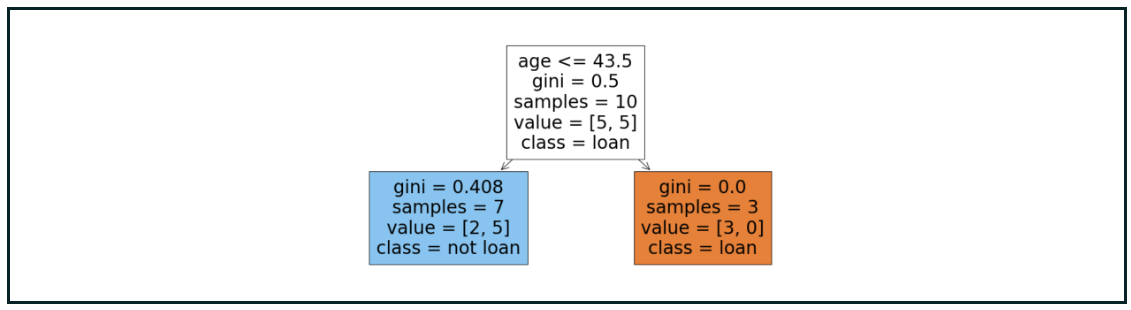

У такого дерева только одна вершина содержит предикат $B_0(x_j,\ t)=[x_j\le t]$ (age )$\leq 43.5$ — она же по совместительству является корневой. Из неё выходят две листовые вершины, которые содержат предсказания, в данном случае — классы объектов (loan — кредит выплачен, not loan — кредит не выплачен).

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Ещё говорят так: корневая вершина в данном случае является <b>родительской</b>, а две другие — её <b>потомками</b>. 

Чтобы построить решающий пень, нам нужно лишь определить, какое решающее правило будет содержаться в корневой вершине. Говоря на языке машинного обучения, нам нужно найти наилучшие по заданному критерию параметры предиката — j и t.

<center>$\color{green}{\text{КАНДИДАТЫ В ПАРАМЕТРЫ РАЗБИЕНИЯ}}$</center>

Как и ранее, мы будем рассматривать простые предикаты вида: 

$$B(x_j,\ t)=[x_j\le t]$$

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Так как мы рассматриваем построение решающего пня, у которого только одна вершина содержит предикат, индекс номера вершины только один — $v=0$. Чтобы постоянно не прописывать этот индекс, его можно опустить.

Из модулей по математическому анализу мы знаем, что, употребляя слово «оптимальный», необходимо делать важную оговорку — оптимальный по какому критерию?

Забегая немного вперёд, давайте введём критерий оптимальности — некоторую меру **неоднородности (impurity)** $G(X,\ y,w)$, которая будет  показывать, насколько большой разброс целевой переменной $y$ для объектов из множества $X$ наблюдается в дочерних вершинах при параметрах сплита $w$. Мы бы хотели построить пень таким образом, чтобы минимизировать эту неоднородность: 

$$G(X,\ y,w)\to min_w\$$

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Иначе говоря, мы хотим сделать так, чтобы разброс ответов в дочерних вершинах был как можно меньше. В идеале необходимо создать такой предикат, чтобы в левую и правую вершины попали как можно наиболее схожие объекты (например, в случае задачи классификации — объекты какого-то одного класса).

Поскольку мы не можем привлечь математические методы оптимизации, будем действовать по старинке — «в лоб».

Параметры $w=(j,\ t)$ можно найти простым перебором. В качестве кандидата на пороговое значение $t$ можно рассматривать среднее значение между двумя соседними уникальными значениями отсортированного фактора $x_j$.

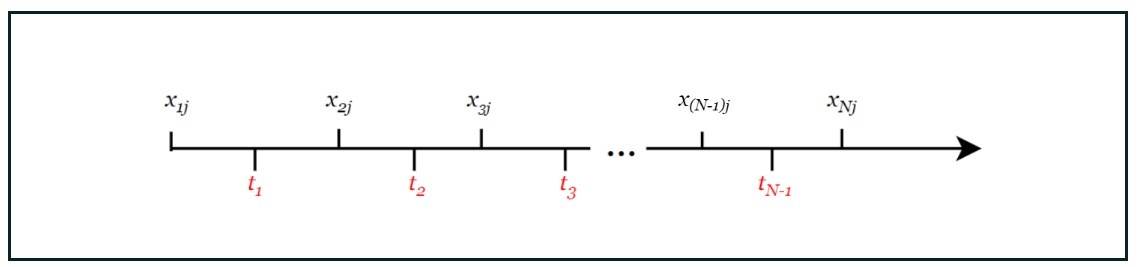

Для каждого из возможных предикатов $B_v(x_j,\ t)$ нам необходимо подсчитать значение неоднородности $G(X,\ y,w)$ на всей выборке и определить такую комбинацию $w_{opt}=(j_{opt},\ t_{opt})$, которая даёт минимум:

$$w_{opt}=argmin_wG(X,\ y,w)$$

In [ ]:
min_loss = inf
optimal_split_params = None
for j in range(M):
    thresholds = find_candidates_for_thresholds(X[:, j], y)
    for t in thresholds:
        split_params = (j, t)
        loss = calculate_loss(X, y, split_params)
        if loss < min_loss:
            min_loss = loss
            optimal_split_params = split_params

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Здесь inf означает бесконечность, то есть до начала работы алгоритма перебора значение переменной min_loss — какое-то очень большое число. 

Итого, если у нас есть $M$ факторов и $N$ наблюдений, то, чтобы найти оптимальные параметры разбиения, нам в худшем случае понадобится перебрать $M(N-1)$ комбинаций. 

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><B>Примечание</B>. Факторы могут быть как числовыми, так и категориальными, и алгоритм CART в общем случае предусматривает работу с обоими видами, однако в sklearn такая функциональность не поддерживается (на июль 2022 года).<br>
Библиотека предполагает, что категориальные признаки закодированы каким-то из способов кодирования и представлены в числовом виде. Так как мы с вами будем акцентировать внимание именно на реализации алгоритма построения деревьев в sklearn, то мы не будем рассматривать работу с категориальными признаками как с текстом.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Посмотрим, как найти параметры разбиения в решающем пне на примере приведённого выше датасета.

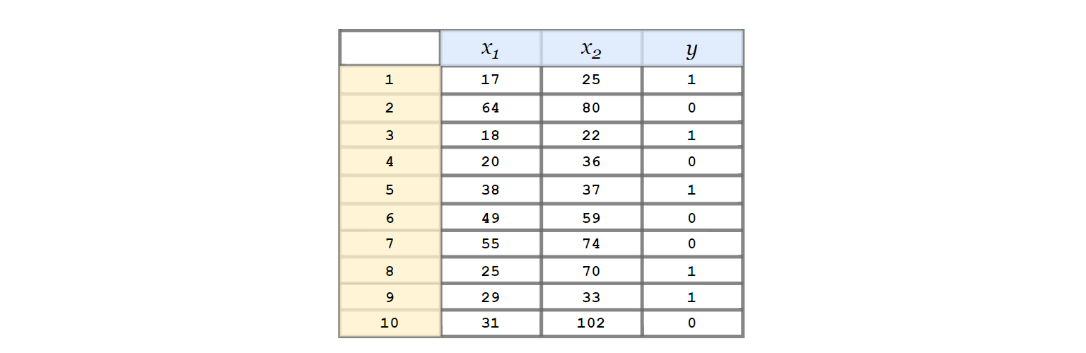

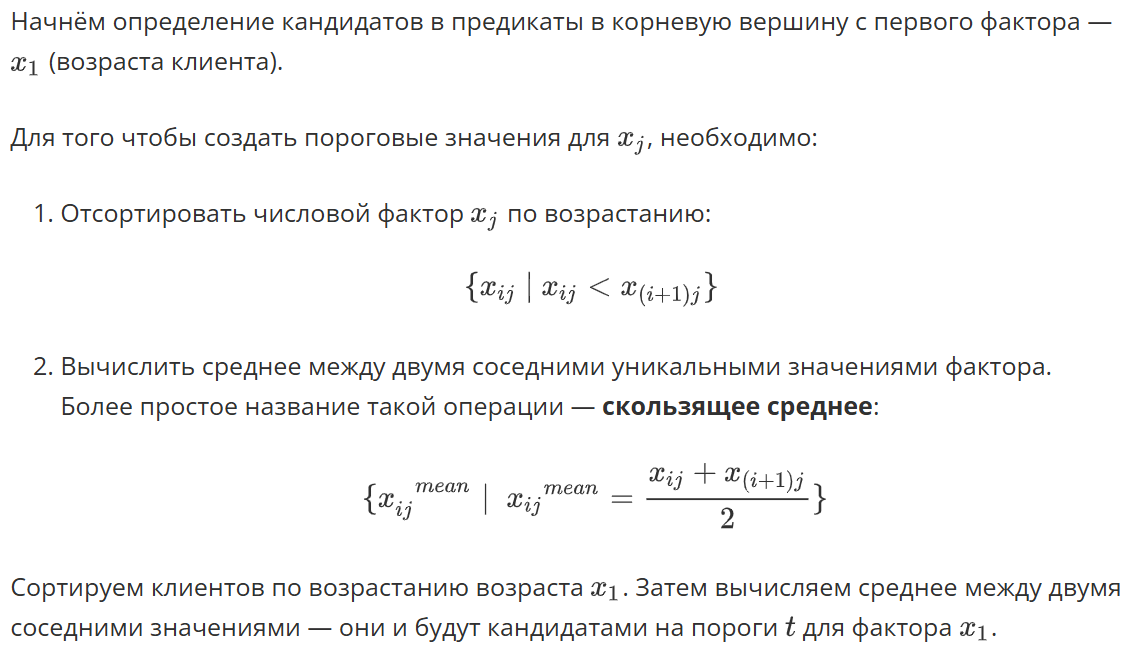

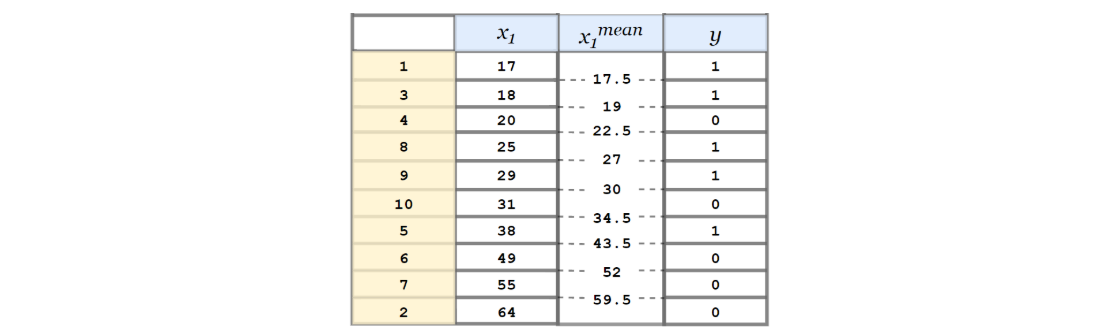

Теперь посмотрим, какие возможные пороговые значения существуют для фактора $x_2$ (дохода клиента). Проделав те же самые операции, получим:

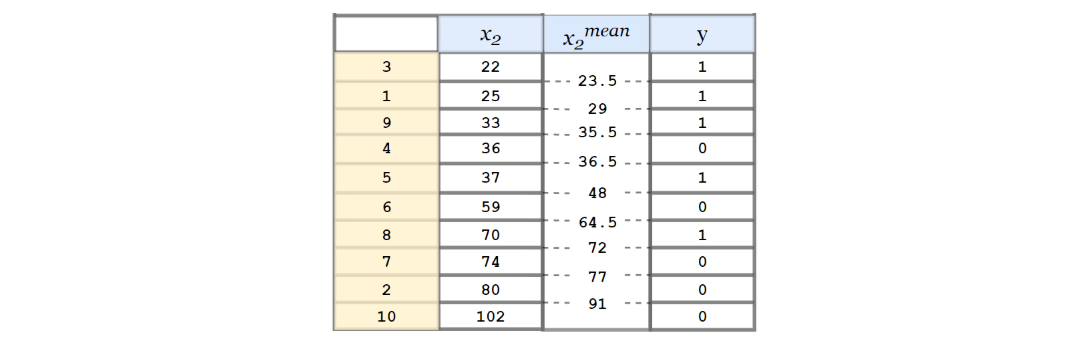

Итак, в качестве кандидатов на предикат корневой вершины $B(x_j,\ t)$ мы выдвигаем следующие решающие правила:

$$[x_1\le 17.5], [x_1\le 19],...,\ [x_1\le 59.5],$$
$$[x_2\le 23.5], [x_2\le 29],...,\ [x_2\le 91]$$

Итого у нас получится $(N-1)\cdot M=9\cdot 2=18$ комбинаций $j$ и $t$. 

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">→ Мы понимаем, что с ростом числа наблюдений $N$ и факторов $M$ количество комбинаций будет очень сильно расти. Представьте себе утрированную (но всё же возможную) ситуацию: у вас есть датасет на $N=10000$ наблюдений и $M=100$ факторов, и каждый из факторов полностью состоит из уникальных значений. В таком случае для того, чтобы построить решающий пень, вам понадобится $N\cdot M=10^6$ операций. Согласитесь, многовато для одной вершины в дереве. И это ещё без учёта того, что факторы в алгоритме CART сортируются, а сортировка — тоже довольно «дорогая» операция.

Поэтому мы будем рассматривать чуть более сложную идею, реализованную в библиотеке sklearn.

<p style="border:3px black solid; text-align: left; padding: 10px"><span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Рассмотрим соседние средние для возраста клиента $x_1$:

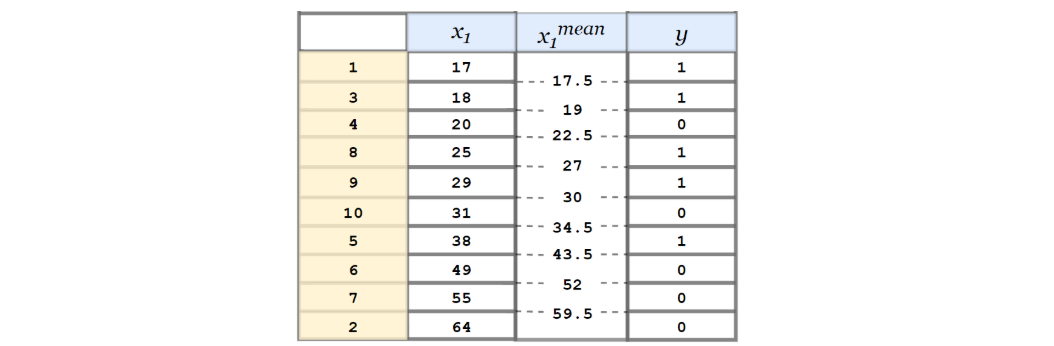

Заметим, что при переходе через пороговое среднее 17,7 класс объекта $y$ не меняется, так же, как, например, при переходе через среднее 27. А вот при переходе через числа 19, 22,5, 30, 34,5 и 43,5 класс 1 меняется на класс 0 и наоборот. 

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>
Возникает вопрос: зачем рассматривать пороги, которые не дают новой информации об изменении целевой переменной?

Верно, незачем — эта информация не приносит никакой пользы и лишь увеличивает количество комбинаций. Поэтому в качестве пороговых значений $t$ для фактора $x_1$ мы будем рассматривать только те соседние средние в отсортированном столбце, при переходе через которые целевая переменная $y$ изменяется (мы отметили их  $\color{red}{\text{красным}}$цветом):

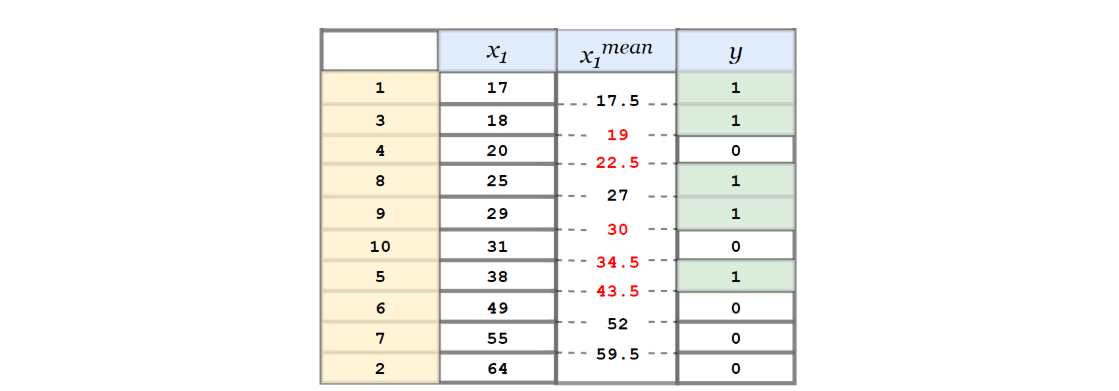

Итого вместо девяти изначальных кандидатов на порог t для признака $x_1$ у нас есть пять.

Применим ту же идею для фактора $x_2$ (дохода клиента). Проделываем те же самые операции. Выберем только те пороговые средние, при которых $y$ меняется с 1 на 0 и наоборот:

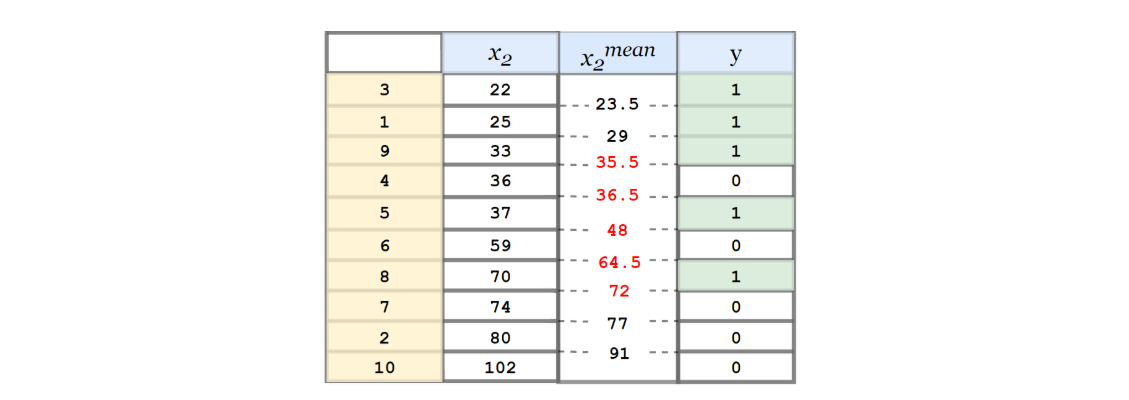

Итого вместо девяти изначальных кандидатов на порог $t$ для признака $x_2$ у нас есть пять.

В качестве кандидатов на предикат корневой вершины $B_0$ мы выдвигаем следующие решающие правила:

$$[x_1\le 19], [x_1\le 22.5],\ [x_1\le 30],\ [x_1\le 34.5],\ \ [x_1\le 43.5],$$
$$[x_2\le 35.5], [x_2\le 36.5],\ [x_2\le 48],\ [x_2\le 64.5],\ \ [x_2\le 72]$$

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Таким образом, мы получили десять комбинаций $j$ и $t$, которые нам необходимо перебрать, чтобы найти оптимальные. Напомним, что в прошлом примере у нас получалось 18 комбинаций, то есть число рассматриваемых для построения решающего пня случаев сократилось почти вдвое.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Конечно, так бывает не всегда: например, если целевая переменная $y$ состоит полностью из уникальных значений, такая методика не сработает. Однако в большинстве практических случаев данная эвристика значительно уменьшает количество итераций и тем самым сокращает время построения дерева решений. 

В качестве **резюме** приведём наш оптимизированный алгоритм определения пороговых значений для фактора $x_j$:

1. Отсортировать числовой фактор $x_j$ по возрастанию:
$$\{x_{ij}\ \mid \ x_{ij}<x_{(i+1)j}\}\$$

2. Вычислить среднее между двумя соседними уникальными значениями фактора:
$${{\{x}_{ij}}^{mean} \mid {{\ x}_{ij}}^{mean}=\frac{x_{ij}+x_{(i+1)j}}{2}\}$$

3. В качестве кандидатов на пороговые значений $t$ выбираются только те значения, при которых целевой признак меняет своё значение:
$${\{x_{ij}}^{mean} \mid \ y_i-y_{(i+1)}\neq 0\}\$$

Теперь, когда мы научились считать вручную, настало время реализовать на Python полученный нами способ определения кандидатов в параметры предиката. Будем это делать на примере признака возраста:<br>
**Cм. MATH&ML-8_DecisionTree_CART/Алгоритмы на основе деревьев решений**

<center>$\color{green}{\text{ВЕТВЛЕНИЕ. НЕОДНОРОДНОСТЬ}}$</center>

Для начала нам потребуется немного сухой математики, а затем мы перейдём к конкретным примерам и посмотрим, как введённые нами формулы работают на практике.

Как и ранее, обозначим пару внутренних параметров корневой вершины j и t для краткости в виде вектора $w=(j, t)$, где $j$ — номер признака, а $t$ — пороговое значение.

Пары объектов и ответов y, соответствующих им, обозначим как $Q={(x, y)}$. Пусть это множество $Q$ содержит $N=|Q|$ объектов из обучающей выборки.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Как сильно ответы в выборке Q различаются между собой? Иначе говоря, какой разброс целевой переменной в выборке Q?

Чтобы это измерить, введём некоторую функцию $H(Q)$, которую назовём **критерием неоднородности (impurity criterion)** или **критерием информативности** (это более распространённое название). 

Предположим, что мы выбрали конкретные параметры w. Тогда множество Q разбивается на две части $(Q^{left}=(X^{left} ,y^{left})$ и $Q^{right}=(X^{right} ,y^{right}))$, для которых условие предиката $B(xj,t)$ выполняется и не выполняется соответственно:

$$Q^{left}={(x, y)∣ xj≤t}$$

$$Q^{right}=Q ∖ Q^{left}={(x, y)∣ xj>t}$$

Каждая из полученных выборок будет иметь свои размеры (мощности множеств) — обозначим их как $N^{left}=|Q^{left}|$ и $N^{right}=|Q^{right}|$.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Насколько уменьшился разброс целевой переменной после сплита с такими параметрами?

Для ответа на этот вопрос необходимо вычислить взвешенную неоднородность $G(Q, w)$ в полученных левой и правой частях:

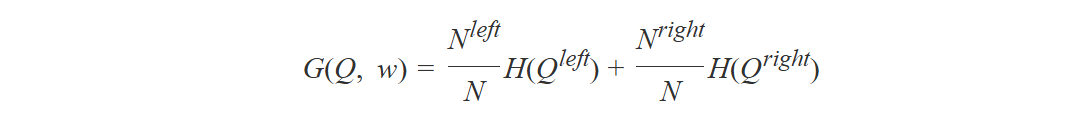

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>И финальный вопрос: какие параметры w нам подойдут?

Нам необходимо выбрать такие параметры $w$ для предиката $B(xj,t)$, при которых неоднородность после ветвления будет наименьшей.

$$G(Q, w)→min_w$$

$$w_{opt}=(j_{opt}, t_{opt})=argmin_w G(Q, w)$$

От вида функции $H(Q)$ зависит, как будет выглядеть итоговое выражение для неоднородности — её значение должно уменьшаться с уменьшением разброса ответов на выборке.

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px">Дополнительно введём такое понятие, как <b>прирост информации (information gain)</b>. Это разница между неоднородностью в вершине до её деления и неоднородностью после деления с параметрами $w$: 

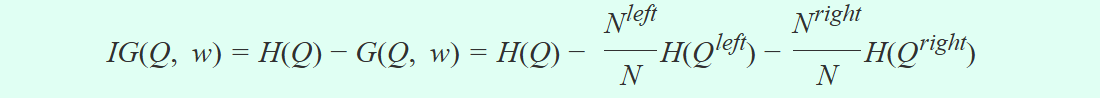

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px">Интерпретация $IG(Q, w)$: сколько новой информации о целевой переменной y удалось получить при использовании предиката $B(xj,t)$.<br>
На основе прироста информации определяется значимость признака $x_j$, о которой мы поговорим в отдельном юните. 

Кстати, можно рассматривать задачу поиска параметров в контексте прироста информации. Тогда нашей целью будет найти максимум прироста информации:

$$IG(Q, w)→max_w$$

Оптимальными будут те параметры $w$, которые дают наибольший прирост информации в результате разбиения:

$$w_{opt}=(j_{opt}, t_{opt})=argmax_w IG(Q, w)$$

Чтобы завершить изучение процедуры построения решающего пня, нам осталось определиться с тем, как измерять неоднородность, иначе говоря, нам нужно определить, какие бывают **критерии информативности**. Вид критерия зависит от задачи, которую мы решаем. Для начала обсудим критерии информативности в задачах регрессии, а затем поговорим о задаче классификации.

<center>$\color{green}{\text{КРИТЕРИИ ИНФОРМАТИВНОСТИ В ЗАДАЧЕ РЕГРЕССИИ}}$</center>

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span><b>Квадратичная ошибка (Squared Error)</b>

В задачах регрессии классической функцией ошибки выступает средний квадрат разницы между истинным ответом $y$ и предсказанием модели $\hat y$
 , или среднеквадратичная ошибка (MSE, Mean Squared Error). Давайте возьмём её в качестве критерия информативности:
 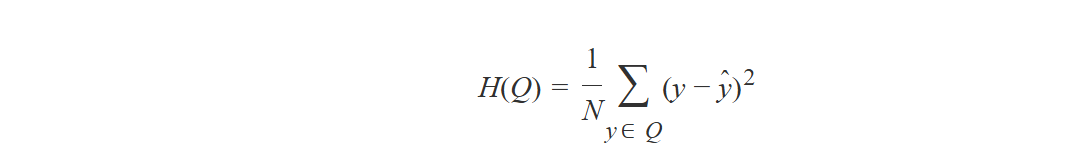

Ранее мы говорили, что в качестве предсказания $\hat y$ модели дерева решений в задачах регрессии вычисляется среднее значение целевой переменной для объектов, попавших в вершину. Обозначаем эту величину как $y$:

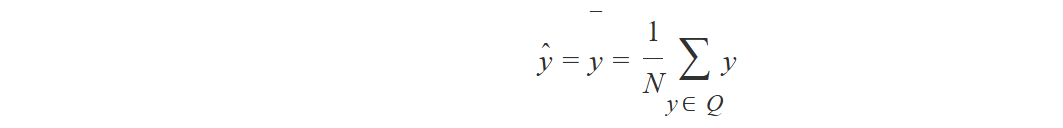

Тогда, подставив значение $\hat y$ в формулу, получим:

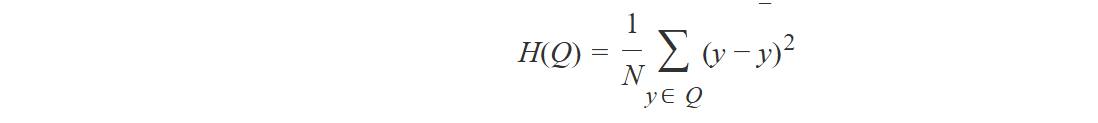

Если присмотреться внимательно, можно заметить, что полученная формула — это формула выборочной дисперсии целевой переменной, т. е. $H(Q)=D(y)$. Таким образом, используя критерий MSE, мы выбираем параметры сплита w так, чтобы взвешенная сумма дисперсий в листьях была как можно меньше, что кажется вполне логичным.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span><b>Абсолютная ошибка (Absolute Error)</b>

Вместо квадрата используем модуль разницы между истиной и предсказанием — получим среднюю абсолютную ошибку *(MAE, Mean Absolute Error)*:

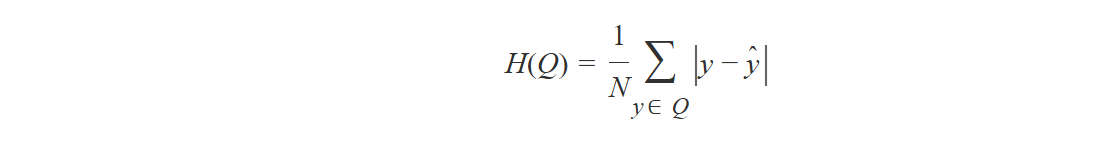

Однако в таком случае в качестве предсказания $\hat y$
  модели дерева решений вычисляется медиана целевой переменной для объектов, попавших в корневую вершину.

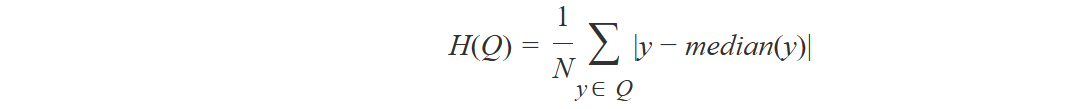

Таким образом, данный критерий информативности измеряет отклонение целевой переменной от медианы.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span><b>Пуассоновская ошибка (Poisson Error)</b>

Последний критерий, предусмотренный в sklearn, — пуассоновская ошибка. Данный критерий используется редко, но он будет хорошим выбором в задачах, где целевая переменная дискретная и подчинена распределению Пуассона (например, количество отказов оборудования).

Формула выводится из распределения Пуассона с помощью [метода максимального правдоподобия](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BC%D0%B0%D0%BA%D1%81%D0%B8%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BF%D1%80%D0%B0%D0%B2%D0%B4%D0%BE%D0%BF%D0%BE%D0%B4%D0%BE%D0%B1%D0%B8%D1%8F). Мы опустим саму процедуру вывода и приведём только конечный вид критерия информативности:

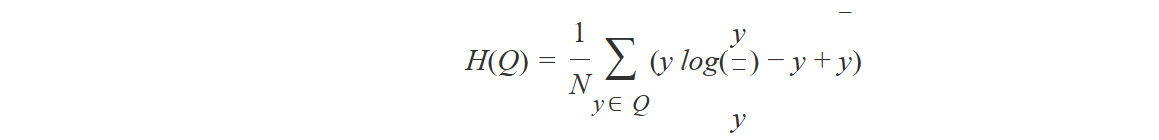

<p style="border:3px black solid; text-align: left; padding: 10px"><span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>Пусть у нас есть некоторый датасет, состоящий из 15 наблюдений (N=15) и одного фактора $x_1$ $(M=1)$. Целевая переменная y является числовой и непрерывной.Необходимо понять, какой набор параметров w является наилучшим для помещения в корневую вершину дерева. Иначе говоря, необходимо построить решающий пень.

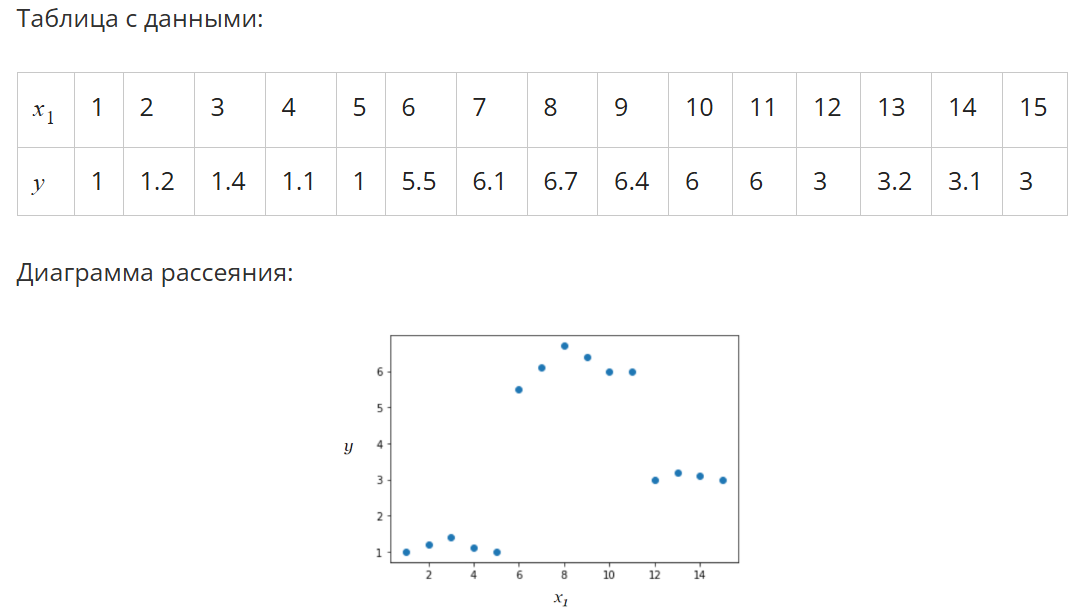

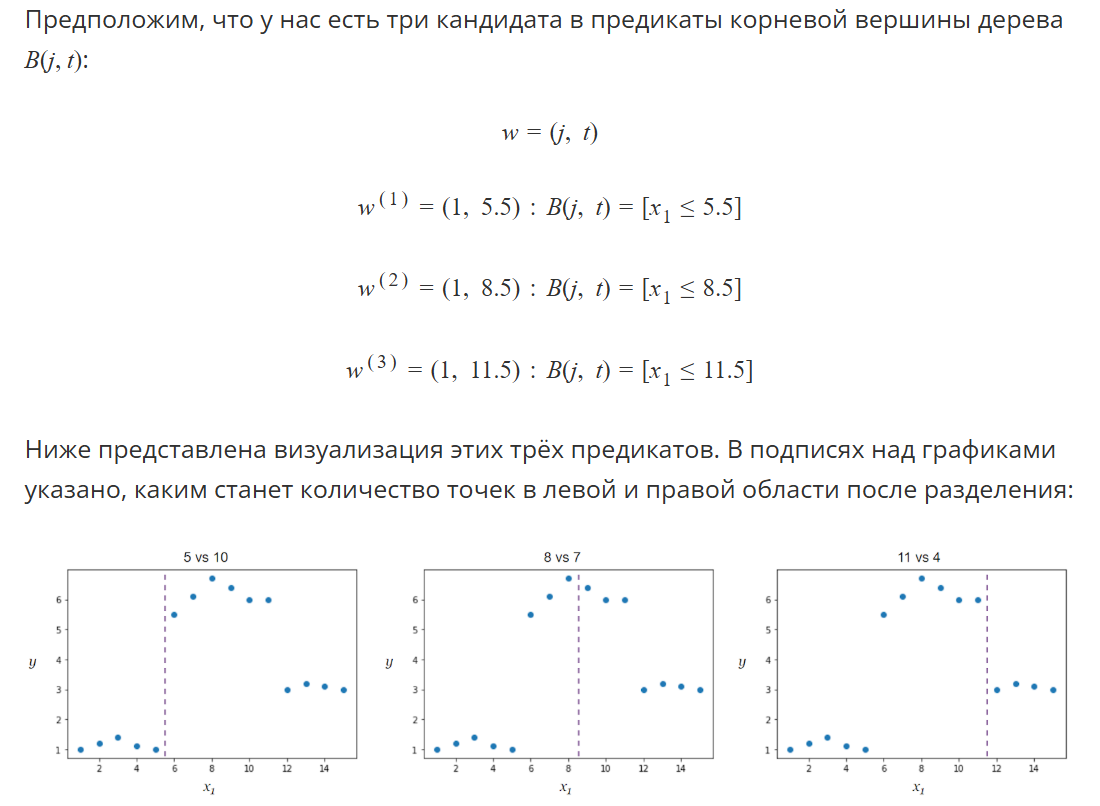

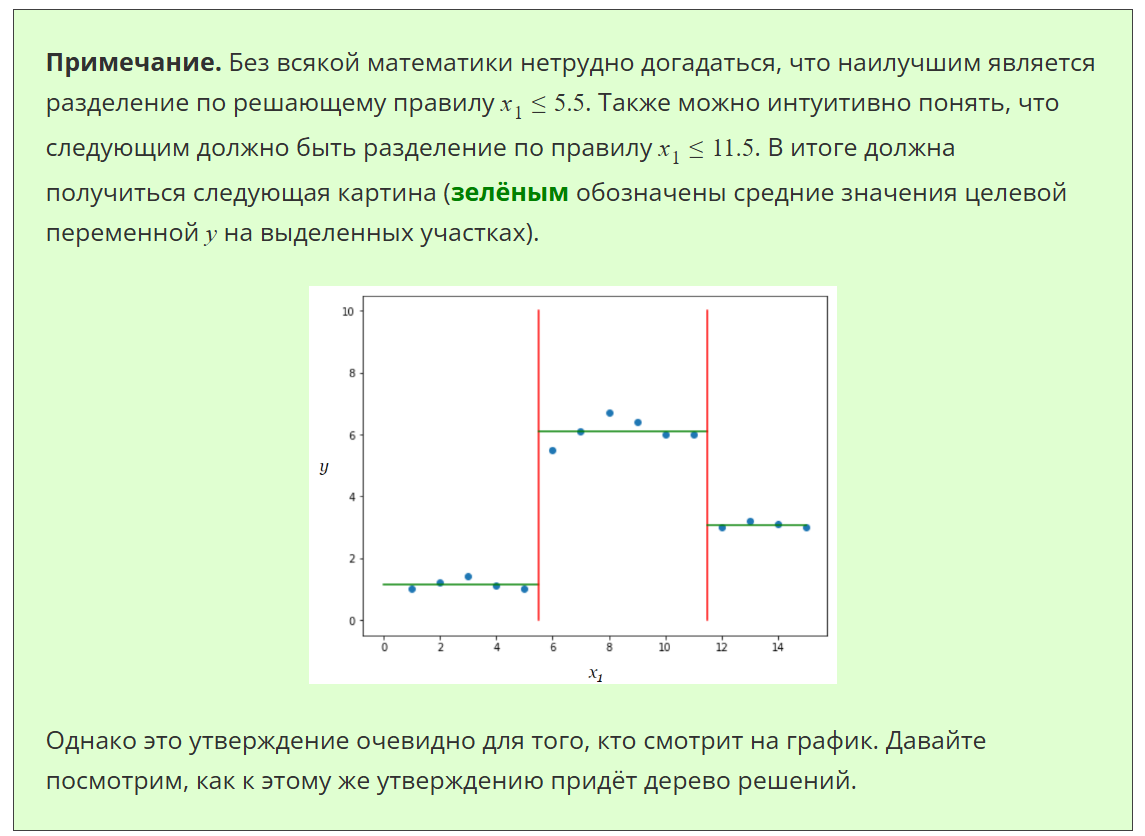

В начальный момент времени в датасете по 15 точек. Рассчитаем начальную неоднородность в вершине.

Сначала считаем предсказание дерева — это будет среднее значение целевой переменной для объектов попавших в вершину, — $y$. Так как корневой вершине соответствует весь датасет, то это просто среднее по $y$:

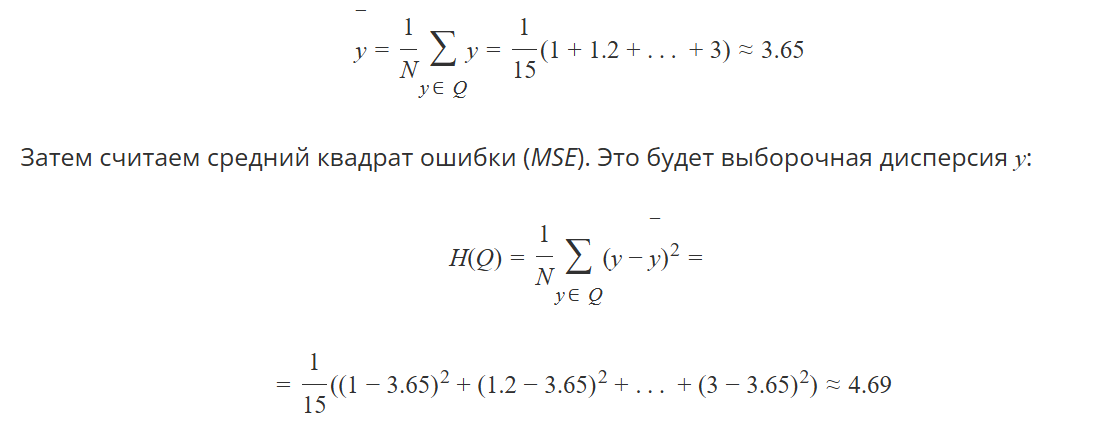

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>При выборе в качестве параметров разбиения $w^{(1)}=(1, 5.5)$ мы получаем предикат $B(j, t)=[x_1≤5.5]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}=5$ точек, а в правую — $N^{right}=10$ точек.

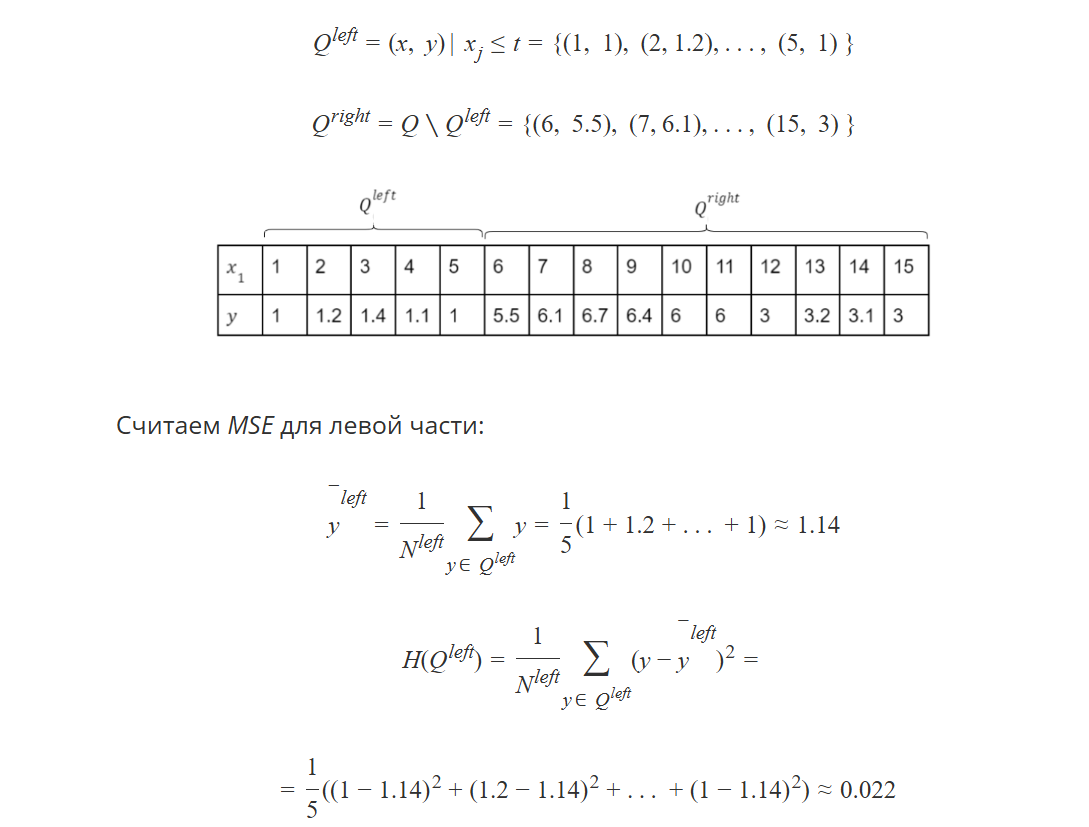

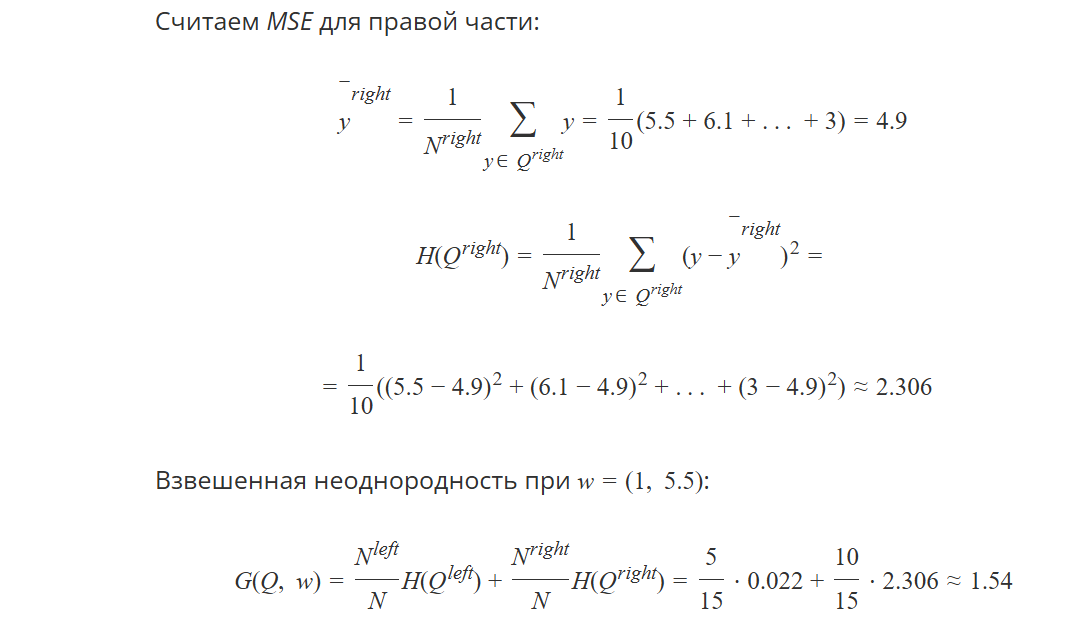

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>При выборе в качестве параметров разбиения $w^{(2)}=(1, 8.5)$ мы получаем предикат $B(j, t)=[x_1≤8.5]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}$=8 точек, а в правую — $N^{right}$=7 точек.

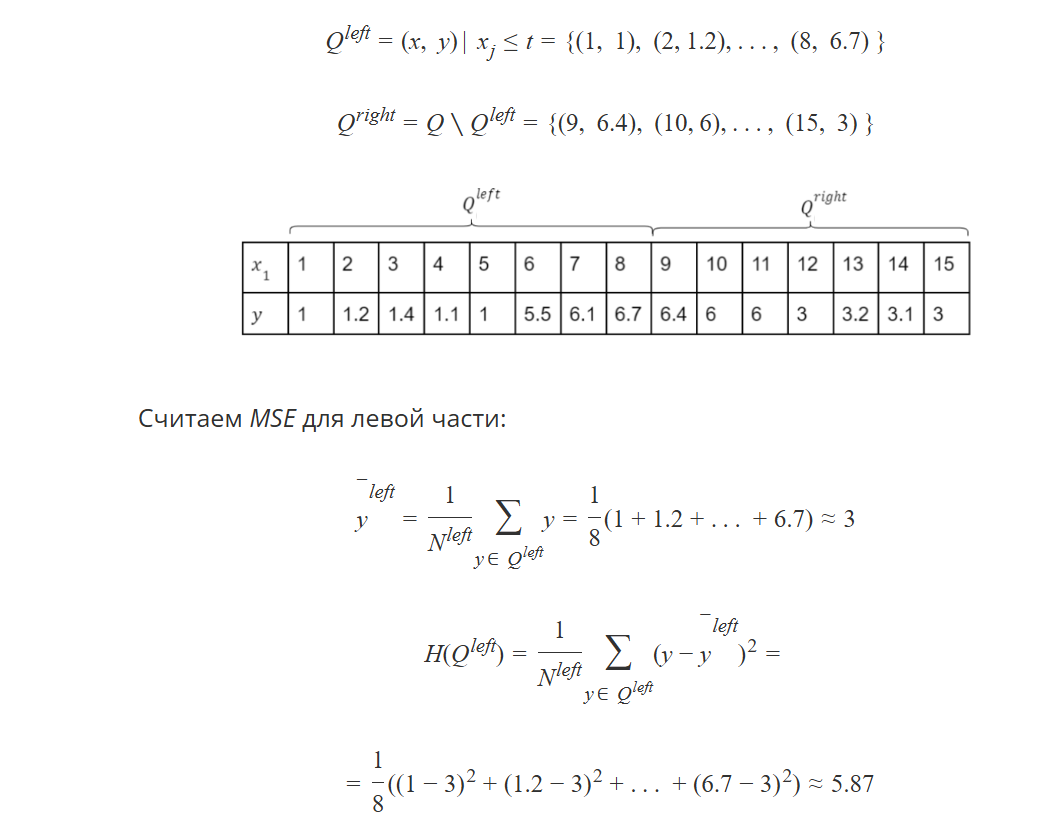

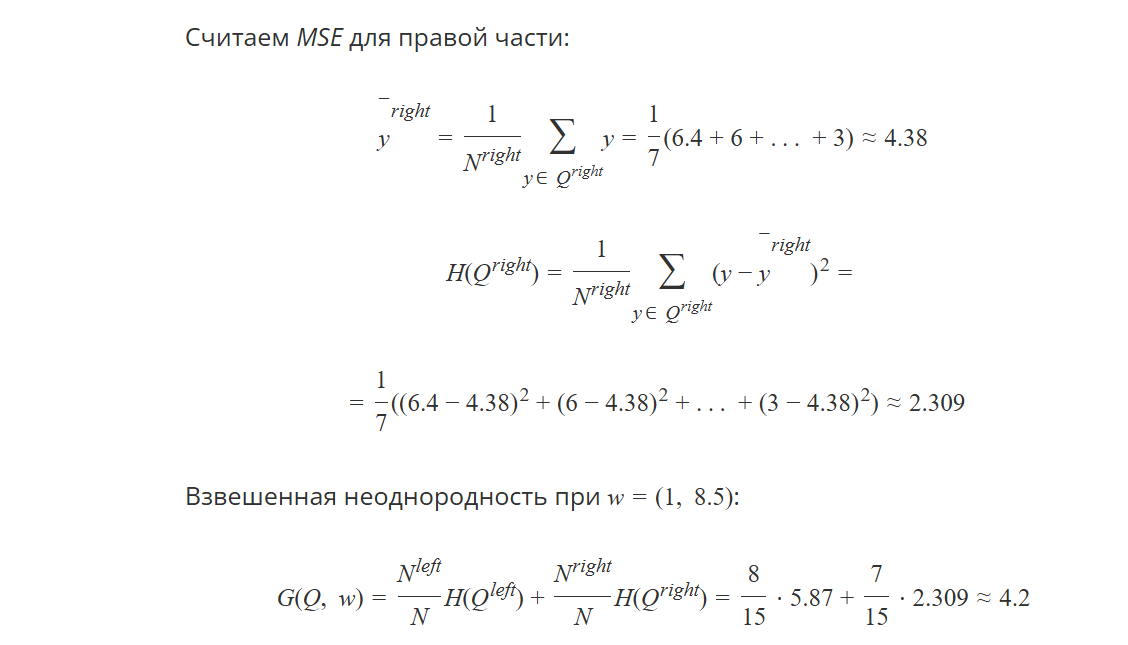

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>При выборе в качестве параметров разбиения $w^{(3)}=(1, 11.5)$ мы получаем предикат $B(j, t)=[x_1≤11.5]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}=11$ точек, а в правую — $N^{right}=4$ точки.

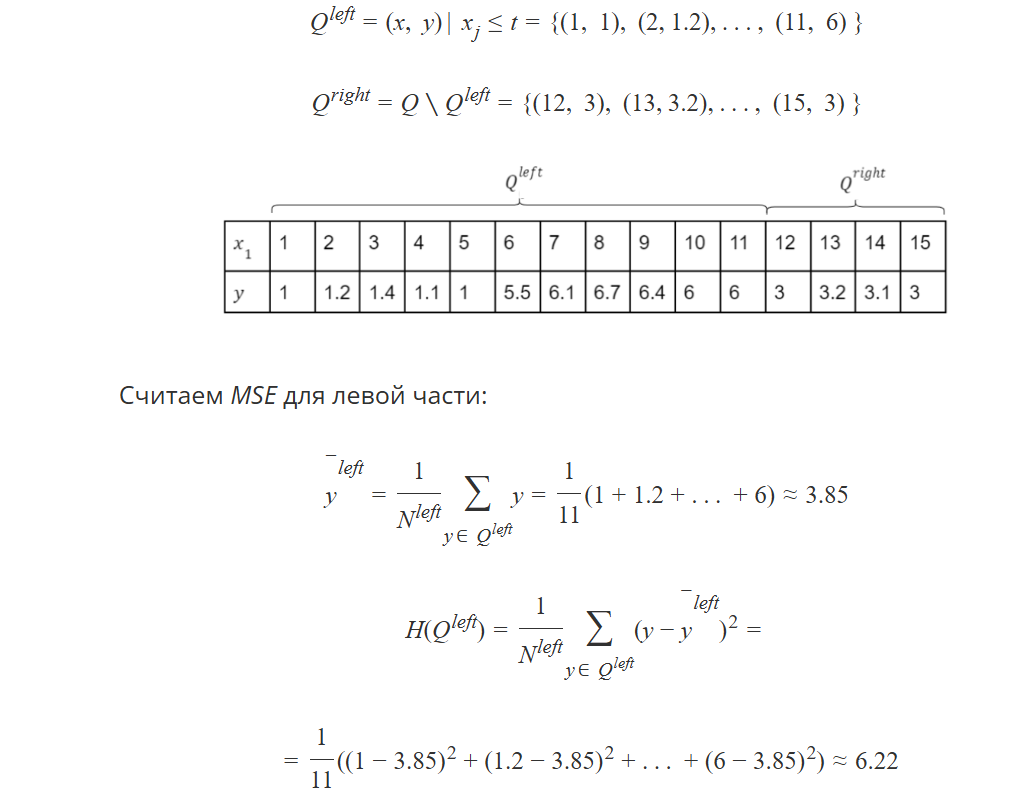

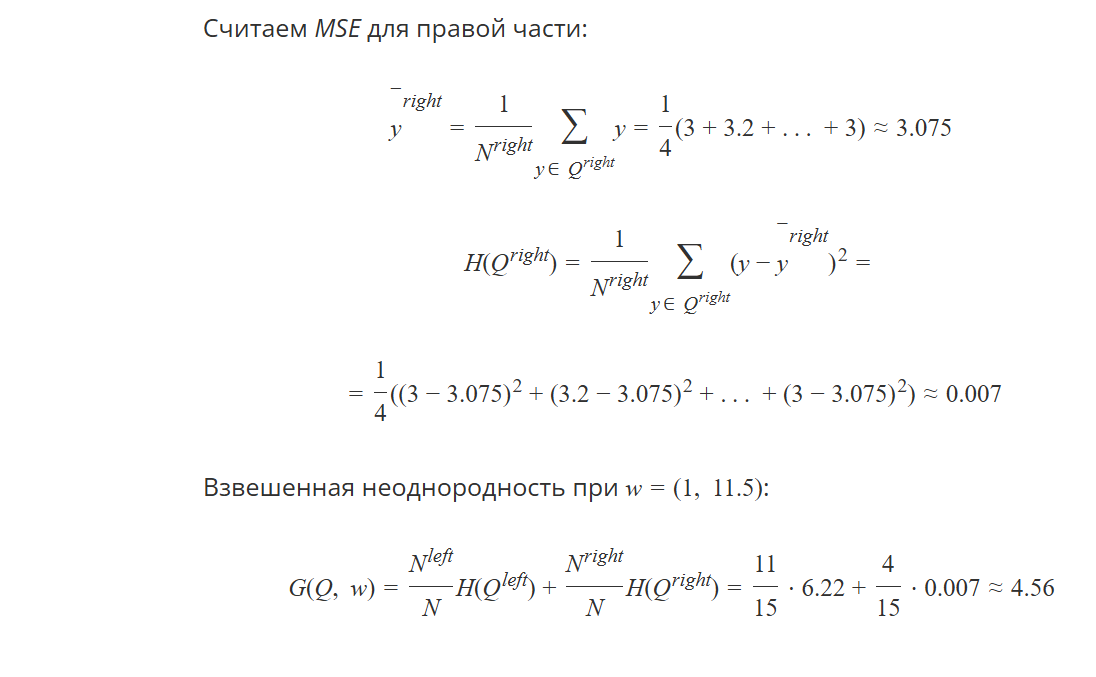

Теперь нам осталось только выбрать такие параметры сплита $w$, при которых $G(Q, w)$ минимальна: $$w_{opt}=(j_{opt}, t_{opt})=argmin_w G(Q, w)=argmin_w([1.54, 4.2, 4.56])=(1, 5.5)$$

Таким образом, оптимальным для помещения в корневую вершину является предикат $B(x_j, t)=[x1≤5.5]$.

Дополнительно посчитаем прирост информации при $w_{opt}$:

$$IG(Q, w_{opt})=H(Q)−G(Q, w_{opt})=4.69−1.54=3.15$$

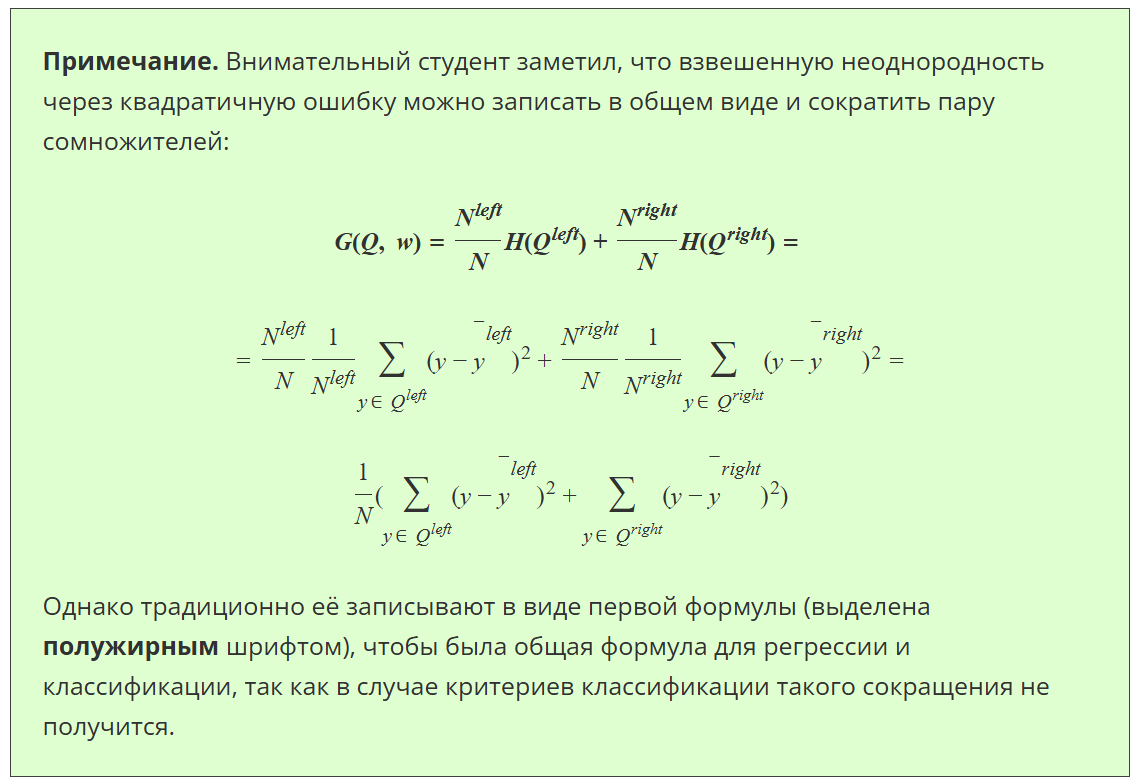

#### Cм. MATH&ML-8_DecisionTree_CART/Алгоритм CART: неоднородность, критерии информативности

<center>$\color{green}{\text{КРИТЕРИИ ИНФОРМАТИВНОСТИ В ЗАДАЧЕ КЛАССИФИКАЦИИ}}$</center>

Все критерии для задачи классификации, которые мы будем рассматривать, основаны на вероятности принадлежности к классу. Пусть у нас есть $K$ классов. Тогда оценка вероятности принадлежности к классу под номером $k$ определяется как:

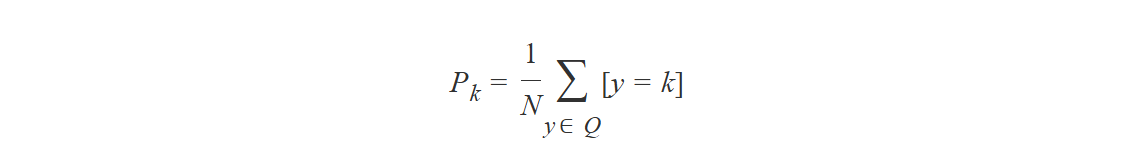

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span><b>Энтропия Шеннона (entropy)</b>

Первый критерий, который мы рассмотрим, — это энтропия Шеннона. Она измеряет непредсказуемость реализации случайной величины.

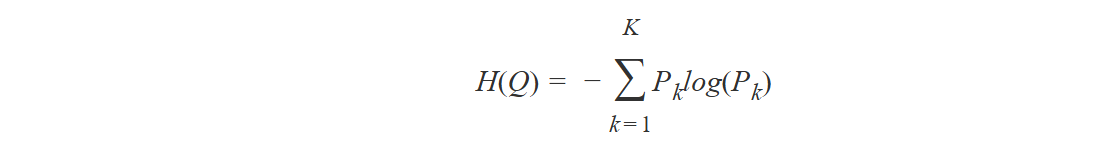

Основание логарифма log на самом деле не имеет значения, но традиционно используется логарифм по основанию 2 (log2).

Данную метрику Шеннон вывел, занимаясь вопросами кодирования строк. Однако затем выяснилось, что полученная формула очень хорошо подходит теории случайных величин. Энтропия численно отражает меру хаоса и активно используется во многих прикладных задачах — от шифрования до машинного обучения.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Когда энтропия минимальна и максимальна?

Найти **минимум** довольно просто. Энтропия неотрицательна, так как все слагаемые неотрицательны — это вероятности, а они не могут быть меньше 0. Значит, минимум энтропии лежит в нуле:

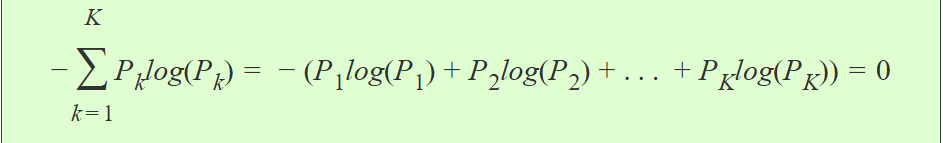

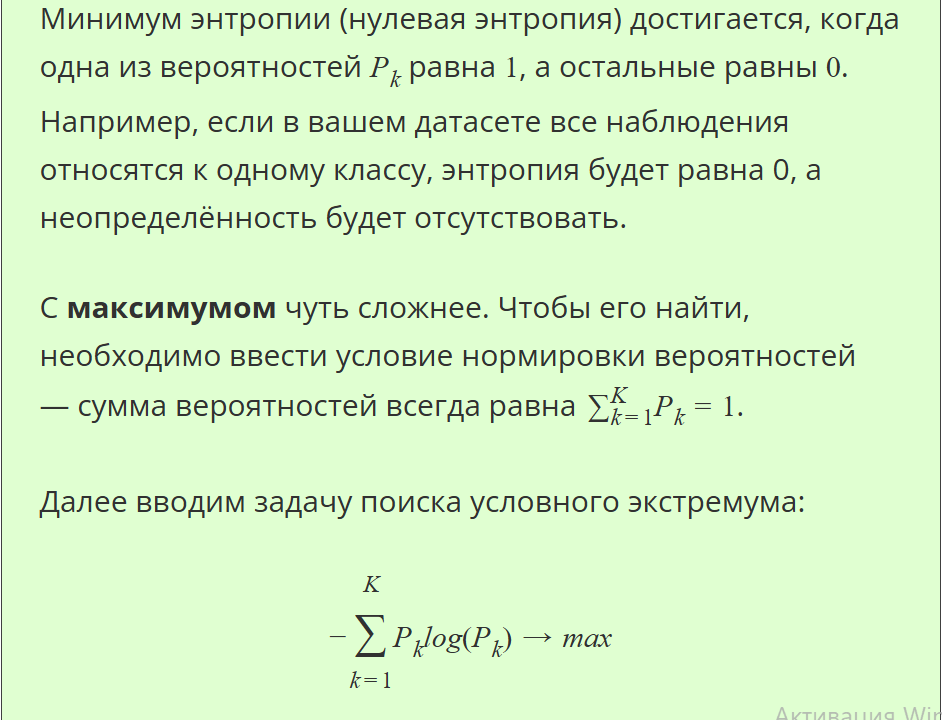

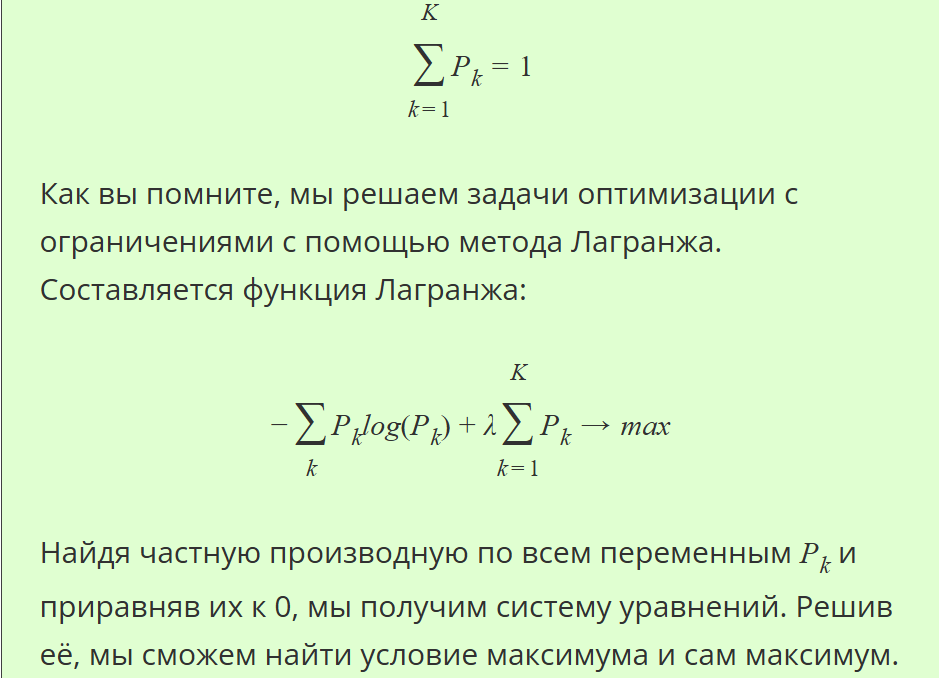

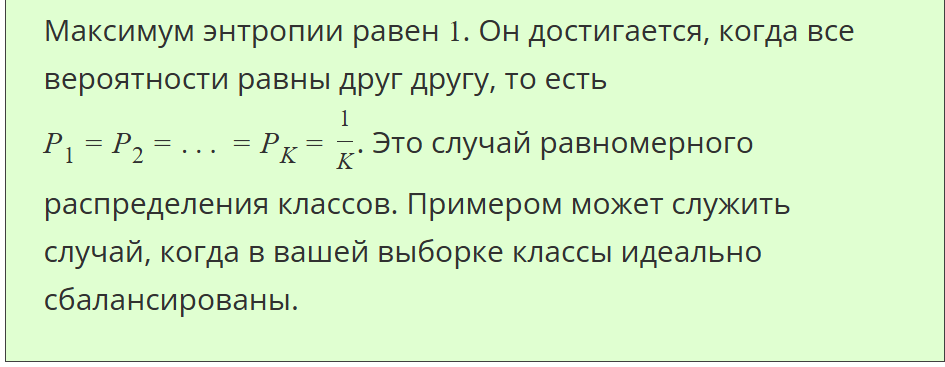

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span><b>Критерий Джини (gini)</b>

Другой способ вычислить неоднородность в случае задачи классификации — воспользоваться критерием информативности Джини:

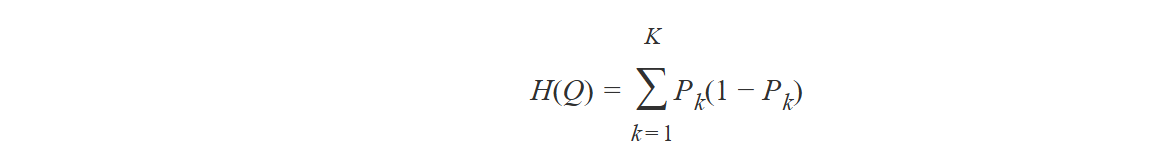

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Предположим, мы хотим угадать, кто изображён на картинке: кошка (класс 1), панда (класс 2) или крокодил (класс 3).
Не глядя на картинку, предполагаем, что на ней кошка. У нас есть только два исхода (угадаем/не угадаем). Эти исходы назовём случайной величиной Z.
Мы уже знаем, что случайная величина Z с двумя исходами $Z=1$ (успех) и $Z=0$ (неудача) подчиняется распределению Бернулли.<br>
Вероятность нашего успеха — это вероятность того, что на картинке кошка,  $P(класс=кошка)=P_1$. Вспоминаем, чему равна дисперсия случайной величины, распределённой по закону Бернулли: $$D(Z)=P_1(1−P_1)$$Если мы проделаем ту же операцию для всех классов, а затем сложим результирующие дисперсии, получим критерий Джини:

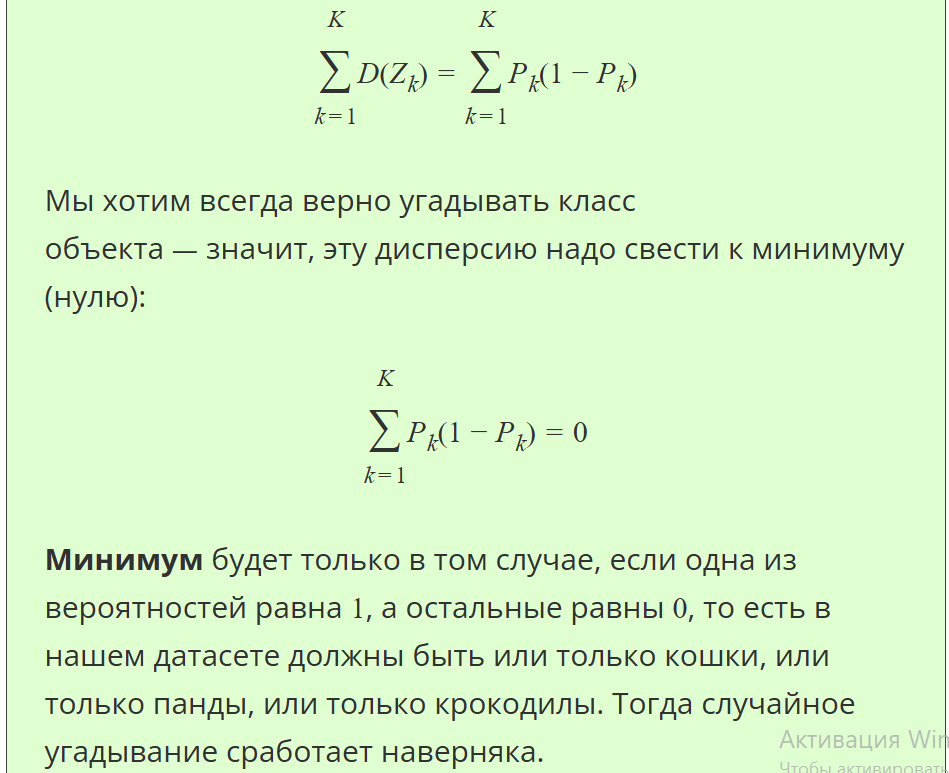

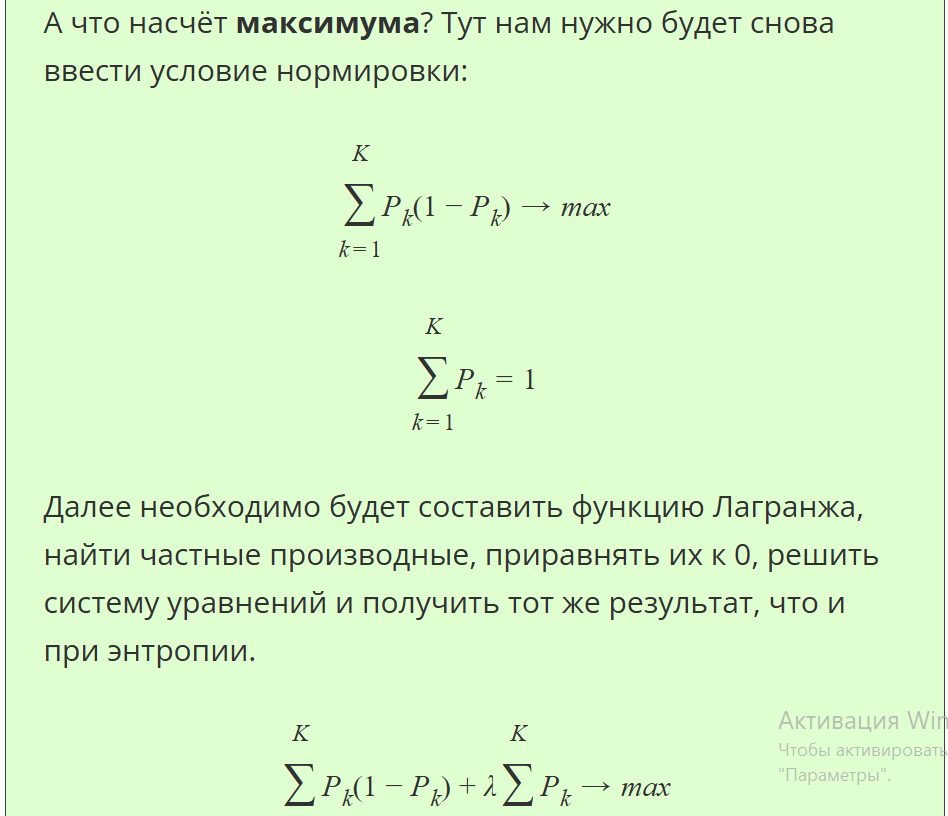

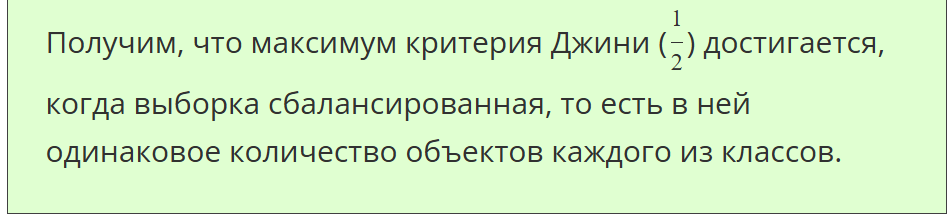

<p style="border:3px black solid; text-align: left; padding: 10px"><span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Пусть у нас есть некоторый датасет, состоящий из 50 наблюдений (N=50) и двух факторов, $x_1$ и $x_2$ (M=2). Целевая переменная y имеет K=2 возможных уникальных значения: 0 и 1. Выборка полностью сбалансирована, то есть в ней присутствует по 25 объектов каждого из классов.

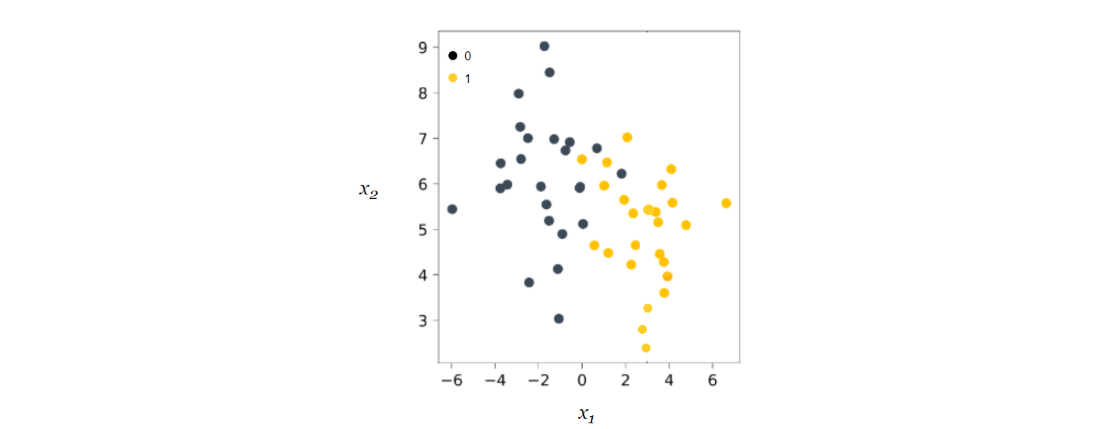

Предположим, что у нас есть три кандидата в предикаты корневой вершины дерева $B(j,t)$:

$$w=(j, t)$$
$$w^{(1)}=(1, 3) : B(j, t)=[x_1≤3]$$
$$w^{(2)}=(1, 0) : B(j, t)=[x_1≤0]$$
$$w^{(3)}=(2, 5.5) : B(j, t)=[x_2≤5.5]$$
Ниже представлена визуализация этих трёх предикатов. В подписях над графиками указано, каким станет соотношение классов в каждой из полученных областей (класс 0 обозначен чёрным цветом, класс 1 — $\color{yellow}{\text{жёлтым}}$):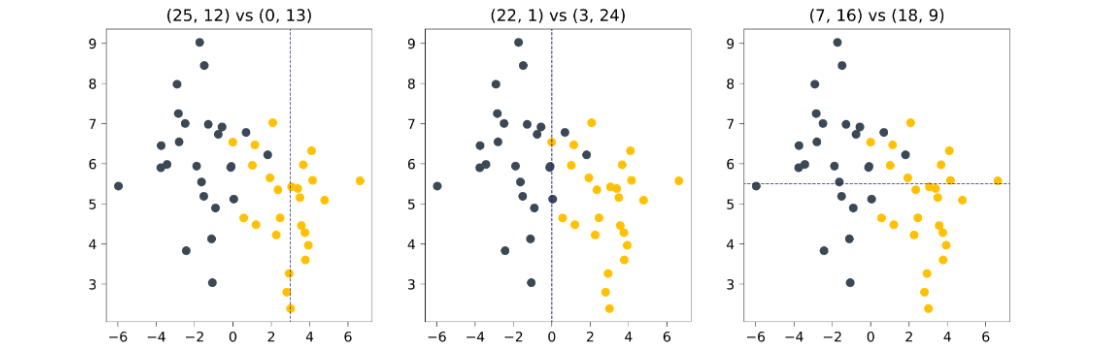

Необходимо понять, какой из предикатов лучше всего подходит для размещения в корневой вершине дерева.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Без всякой математики видно, что наилучшим является разделение по предикату $[x_1≤0]$ — оно обеспечивает практически идеальное разделение на классы.

Однако это очевидно лишь для того, кто смотрит на график. Давайте проследим, как к этому же утверждению придёт дерево решений.

В начальный момент времени в датасете есть по 25 точек каждого из классов.

Энтропия начального состояния равна:

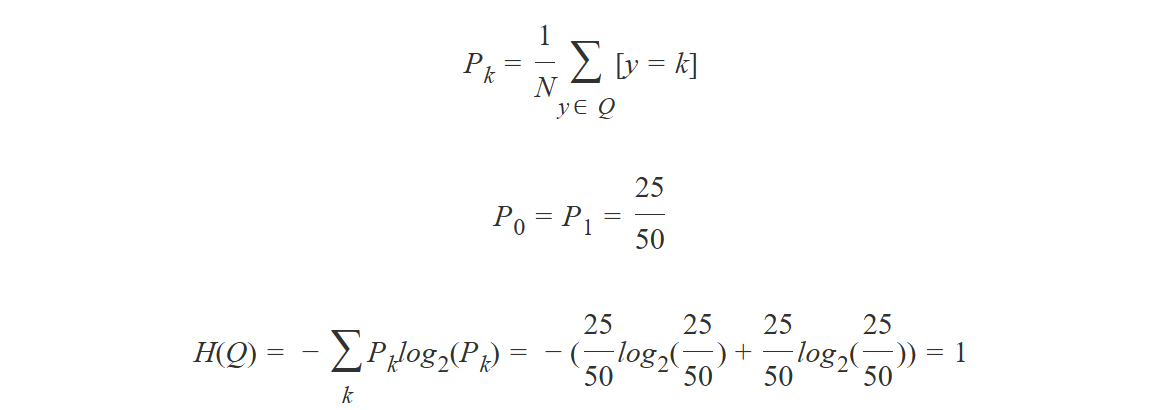

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>При выборе в качестве параметров разбиения $w^{(1)}=(1, 3)$ мы получаем предикат $B(j, t)=[x_1≤3]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}=37$ точек (из них 25 чёрных и 12 жёлтых), а в правую — $N^{right}=13$ точек (все из них являются жёлтыми). 

Энтропия левой части:

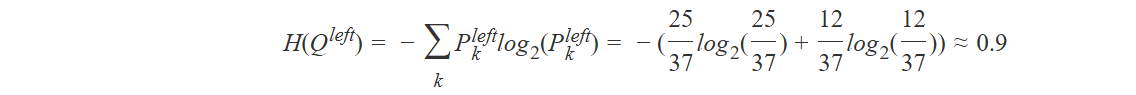

Энтропия правой части:

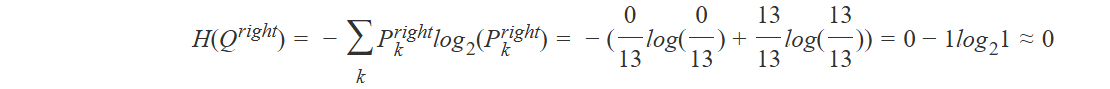

Взвешенная неоднородность при $w=(1, 3)$:

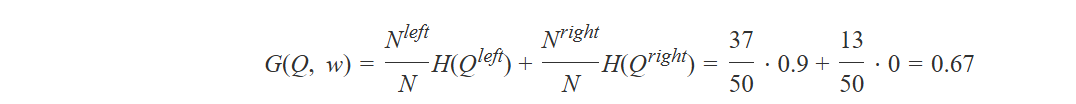

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>При выборе в качестве параметров разбиения $w^{(2)}=(1, 0)$ мы получаем предикат $B(j, t)=[x_1≤0]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}=23$ точки (из них 22 чёрных и 1 жёлтая), а в правую — $N^{right}=27$ точек (из них 3 чёрных и 24 жёлтых).

Считаем, чему равна неоднородность такого состояния.

Энтропия левой части:

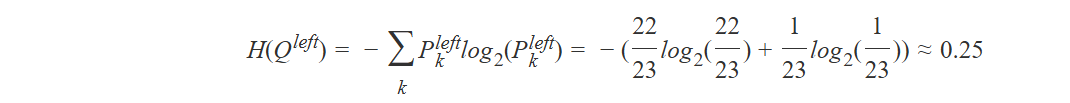

Энтропия правой части:

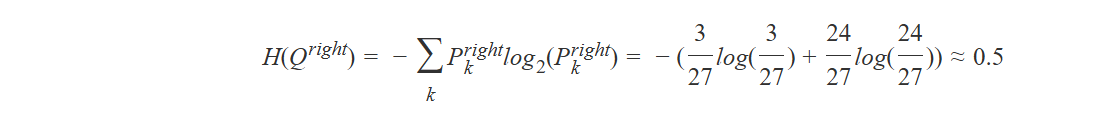

Итоговая неоднородность при $w=(1, 0)$:

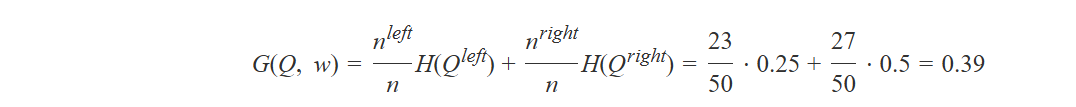

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>При выборе в качестве параметров разбиения $w^{(3)}=(2, 5.5)$ мы получаем предикат $B(j, t)=[x_2≤5.5]$, который разбивает множество объектов и ответов к ним $(Q)$ на две части — $Q^{left}$ и $Q^{right}$. В левую часть попадает $N^{left}=23$ точки (из них 7 чёрных и 16 жёлтых), а в правую — $N^{right}=27$ точек (из них 18 чёрных и 9 жёлтых).

Считаем чему равна неоднородность такого состояния.

Энтропия левой части:

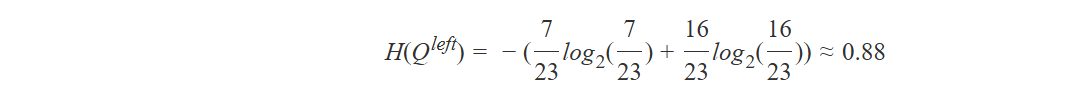

Энтропия правой части:

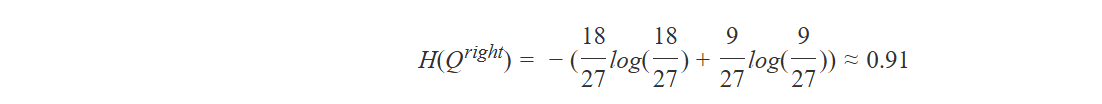

Итоговая неоднородность при $w=(2, 5.5)$:

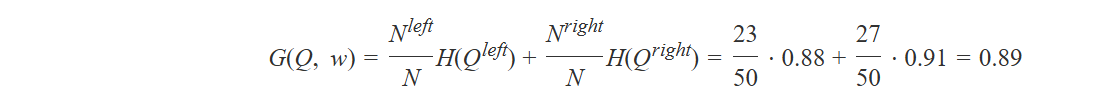

Теперь осталось только выбрать такие параметры предиката $w$, при которых $G(Q,w)$ минимальна:

$$w_{opt}=(j_{opt}, t_{opt})=argmin_w G(Q,w)=argmin_w([0.67, 0.39, 0.89])=(1, 0)$$

Таким образом, оптимальным для размещения в корневой вершине является предикат$ B(xj, t)=[x_1≤0$], что вполне ожидаемо. 

Прирост информации в таком случае будет равен:

$$IG(Q, w_{opt})=H(Q)−G(Q, w_{opt})=1−0.39=0.71$$

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Как изменится код для поиска оптимальных параметров разбиения для задачи классификации?

Сам алгоритм не изменится — просто вместо расчёта квадратичной ошибки мы будем рассчитывать критерий информативности для классификации, например энтропию.

Реализуем функцию *entropy()*, которая рассчитывает энтропию Шеннона. На вход функции приходит целевая переменная y. Далее с помощью функции *value_counts()* считаются доли каждого из классов — вероятности принадлежности к классам. Затем эти вероятности логарифмируются по основанию 2, и наконец по приведённой выше формуле рассчитывается энтропия.

In [1]:
def entropy(y):
    p = y.value_counts(normalize=True)
    entropy = -np.sum(p * np.log2(p))
    return entropy

Для вызова самой функции *best_split()* нужно будет только поменять критерий информативности (параметр *criterion*). Пример:

In [ ]:
optimal_params = best_split(X, y, criterion=entropy)

<center>$\color{green}{\text{*ПАРАЛЛЕЛЬНЫЕ ВЫЧИСЛЕНИЯ НЕОДНОРОДНОСТИ}}$</center>

 <p style="background: #ffc7c7; border:1px black  solid; text-align: left; padding: 10px">Мы рассмотрели два «игрушечных» примера построения корневой вершины дерева для задач регрессии и классификации. При этом мы брали всего по три возможных кандидата в предикаты. В реальности данных и кандидатов в параметры разбиения значительно больше. Представьте, сколько вычислений производит компьютер при построении, казалось бы, простой модели дерева решений.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">⭐ Идея! Раз все вычисления производятся на компьютере, можно использовать <b>параллельные вычисления на многоядерном процессоре</b> и считать неоднородность G(Q,w) для каждой комбинации w параллельно с другими, тем самым значительно повышая скорость построения дерева решений. Эта идея активно используется во многих библиотечных реализациях алгоритма CART, включая sklearn.

##  5. Алгоритм CART: рекурсия, критерии остановки

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Легко убедиться, что для любой выборки можно построить решающее дерево, не допускающее на ней ни одной ошибки. Даже с простыми предикатами $[x_j\le t]$ можно сформировать дерево, в каждом листе которого находится ровно по одному объекту выборки. По своему практическому опыту мы уже знаем, что, скорее всего, это дерево будет переобученным из-за слишком большого количества листьев, и выглядеть оно будет примерно так:

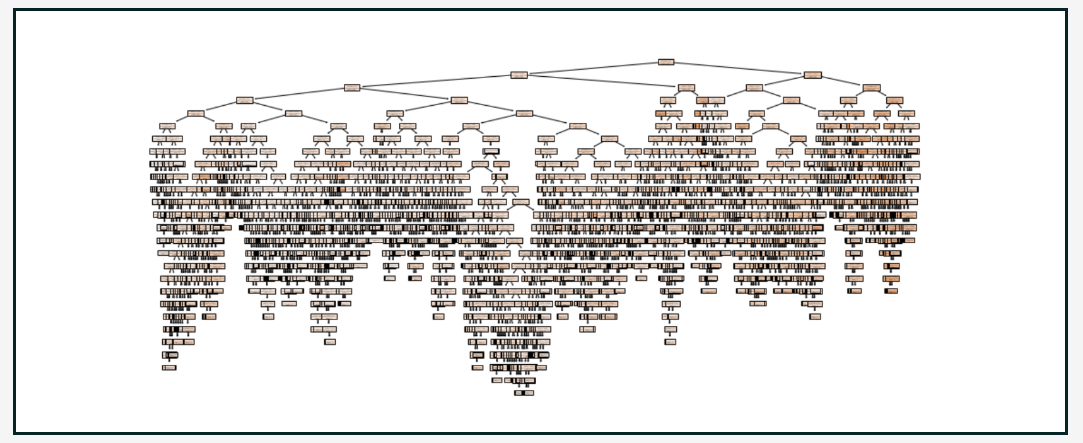

Очевидно, что настолько громоздкие деревья нам не подойдут.

Тогда можно было бы поставить задачу поиска дерева, которое является минимальным (с точки зрения количества листьев) среди всех деревьев, не допускающих ошибок на обучении — в этом случае можно было бы надеяться на наличие у дерева обобщающей способности. К сожалению, было доказано, что эта задача является слишком сложной (если быть точнее, [NP-полной](https://ru.wikipedia.org/wiki/NP-%D0%BF%D0%BE%D0%BB%D0%BD%D0%B0%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0)), а время построения дерева неприемлемо велико.

Как тогда быть? Придётся отказаться от идеи поиска оптимальной структуры дерева. Будем искать не всю структуру дерева целиком, а строить его уровень за уровнем, последовательно.

Схематично **поэтапное построение дерева решений** выглядит следующим образом:

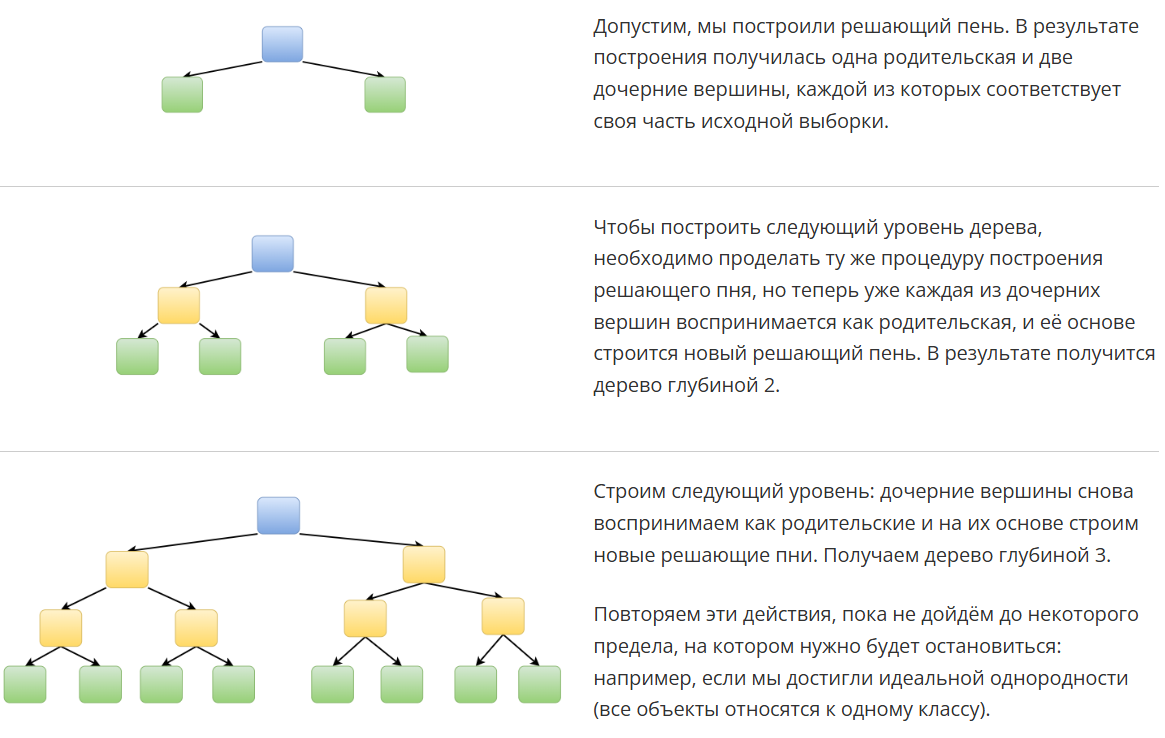

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Формально такой последовательный алгоритм построения дерева относится к категории жадных алгоритмов. 

Внимательные студенты уже догадались, что описанная нами процедура построения дерева является **рекурсией**. Мы рекурсивно используем алгоритм построения решающего пня для каждой из дочерних вершин, тем самым создавая всё новые и новые вершины графа

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Отметим, что, так как мы теперь рассматриваем не решающие пни, а деревья произвольной глубины, то в наших рассуждениях появится <b>индекс вершины дерева</b> $v$ . Он вводится для того, чтобы обозначить, что та или иная величина рассчитывается для конкретной вершины.

Итак, пусть ;Q_v=\{(x,\ y); — множество объектов и ответов к ним, попавших в вершину с номером $v$, $N_v = \left|Q_v \right|$. Пусть задан критерий информативности $H(Q)$, который зависит от задачи (регрессия — Squared Error, Absolute Error или Poisson Error, классификация — Gini или Entropy). Также задан некоторый критерий остановки рекурсии $stop\_criterion(Q_v)$. О том, какими могут быть критерии остановки, мы поговорим чуть позже.

Наш **алгоритм построения дерева решений CART** будет выглядеть следующим образом:

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span>Создаём вершину под номером $v$. 

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span>По умолчанию ветвление дерева решений прекращается, когда достигается однородность, то есть $H(Q_v)=0$

- **2.1. Если условие остановки выполнено**.

    Формируем листовую вершину $v$ и ставим в соответствие этому листу ответ, который будет выдаваться для новых объектов, которые дойдут до этого листа. Назовём эту часть *create_leaf()*.

   - В случае задачи регрессии ответ вычисляется как среднее (если критерий информативности $H(Q)$ — Squared Error или Poisson Error) или медиана (если критерий информативности — Absolute Error):

$${\hat{y}}_v=\frac{1}{N_v}\sum_{y\ \in \ Q_v}{}y$$ <center>или</center> $${\hat{y}}_v=median_{y\ \in \ Q_v}(y)$$

   - В случае задачи классификации ответ вычисляется как метка самого популярного среди объектов $X_v$ класса или как оценки вероятностей принадлежности $P_{vk}$ к каждому из классов:

$$P_{vk}=\frac{1}{N_v}\sum_{y\ \in \ Y_v}{}[y=k],$$ 
$${\hat{y}}_v=argmax_{k\in K}(P_{vk})$$

- **2.2. Если условие остановки не выполнено**
  Строим решающий пень. Формируем решающее правило $B_{v}(x_j,\ t)$ для вершины $v$. Из возможных комбинаций $w=(j,\ t)$ выбираем такую, которая определяет наилучшее разбиение текущего множества объектов и ответов к ним $Q_v$ на две части: $Q^{left}=\{(x,\ y) \mid \ x_j \le t\}$ — левую, для которой условие предиката истинно, и $Q^{right}_v=\{(x,\ y) \mid \ x_j >t\}$ — правую, для которой условие предиката ложно:$$G(Q,\ w)=\frac{N^{left}_v}{N_v}H(Q^{left}_v)+\frac{N^{right}_v}{N_v}H(Q^{right}_v)$$
$$w_{opt}=(j_{opt},\ t_{opt})=argmin_w\ G(Q,\ w)$$
$$B_{\nu }(x_j,\ t)=[x_{j_{opt}}\le t_{opt}]$$
Эту часть алгоритма мы обозначали ранее как *best_split()*.<br>
В результате разбиения будут созданы два подмножества объектов — $Q^{left}_v$ и $Q^{right}_v$. На основе этих подмножеств мы с помощью рекурсии создадим две новые вершины дерева (левую и правую) и свяжем их с текущей вершиной.<br>
Для выборок $Q^{left}_v$ и $Q^{right}_v$ процедура будет повторяться рекурсивно, пока не выполнится критерий остановки.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span>Возвращаем созданную вершину.

#### См. MATH&ML\Примеры решения\MATH&ML-8_DecisionTree_CART\Алгоритм CART: рекурсия, критерии остановки

<center>$\color{green}{\text{КРИТЕРИИ ОСТАНОВКИ}}$</center>

<p style="background: aquamarine;  border:1px black solid; text-align: left; padding: 10px">Как мы уже знаем, любая рекурсия всегда должна имеет <b>критерий остановки</b> — условие, при котором рекурсивный вызов прекращается.

В нашем случае также должно быть такое условие, а лучше целый набор условий, при которых ветвление дерева прекратится. В нашем алгоритме мы назвали данный шаг $stop\_critetion(Q_v)$.

В реализации дерева решений в sklearn предусмотрено несколько критериев, при выполнении одного из которых ветвление дерева прекращается. Мы рассмотрим основные из них на примере нашего «игрушечного» датасета о выплатах кредита.

In [3]:
data = pd.DataFrame({
    'age': [17, 64, 18, 20, 38, 49, 55, 25, 29, 31],
    'income': [25, 80, 22, 36, 37, 59, 74, 70, 33, 102],
    'y': [1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
})
# Создаём обучающую выборку
X = data[['age', 'income']]
y = data['y']

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>1</strong></span><b>Достижение однородности<b>

Этот критерий остановки мы уже использовали при построении своего дерева. Он является основным, то есть действует, если исследователем не установлены другие ограничения.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Критерий гласит: ветвление дерева решений прекращается, когда неоднородность вершины, определяемая критерием информативности? минимальна, то есть $H(Q)=0$

Для задачи **классификации** это условие означает, что все объекты в вершине являются объектами одного класса.

Для задачи **регрессии** это условие означает, что средняя ошибка предсказания вершины равна нулю.

Для примера построим дерево решений, используя наш «игрушечный» датасет. При этом все параметры оставим по умолчанию. Получим следующее дерево:

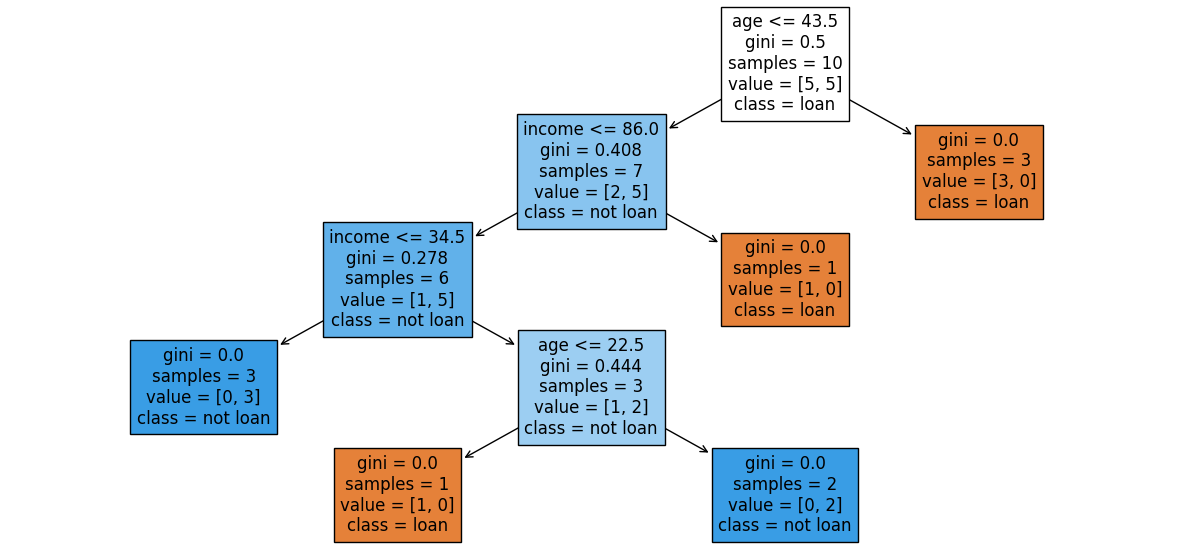

In [6]:
from sklearn import tree
import matplotlib.pyplot as plt

dt = tree.DecisionTreeClassifier(random_state=42)
dt.fit(X, y)


fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Обратите внимание, что во всех листовых вершинах (мы выделили их $\color{red}{\text{красным}}$) неоднородность, обозначенная как *gini*, равна 0, а в самих листьях содержатся объекты (*value*) только одного определённого класса.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>2</strong></span><b>Ограничение максимальной глубины дерева (параметр max_depth)</b>

Это самый простой критерий. Мы работали с ним уже десятки раз, используя деревья решений для задач классификации и регрессии.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Идея состоит в том, что, когда дерево достигает максимально заданной глубины, ветвление прекращается. С точки зрения программной реализации, это означает ограничение глубины рекурсии.

По умолчанию глубина дерева не ограничена. Помните, что ограничение глубины дерева решений является основным методом борьбы с его переобучением.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>3</strong></span><b>Ограничение максимального количества листьев в дереве (параметр max_leaf_node)</b>

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Здесь всё происходит по аналогии с максимальной глубиной дерева: мы задаём максимальное количество листьев, которое может быть в дереве — когда количество листьев в дереве достигает этой верхней планки, ветвление прекращается.

По умолчанию количество листьев не ограничено. Как и все критерии остановки, ограничение на количество листьев может служить инструментом борьбы с переобучением дерева.

Для примера ограничим количество листьев в нашем дереве до 3:

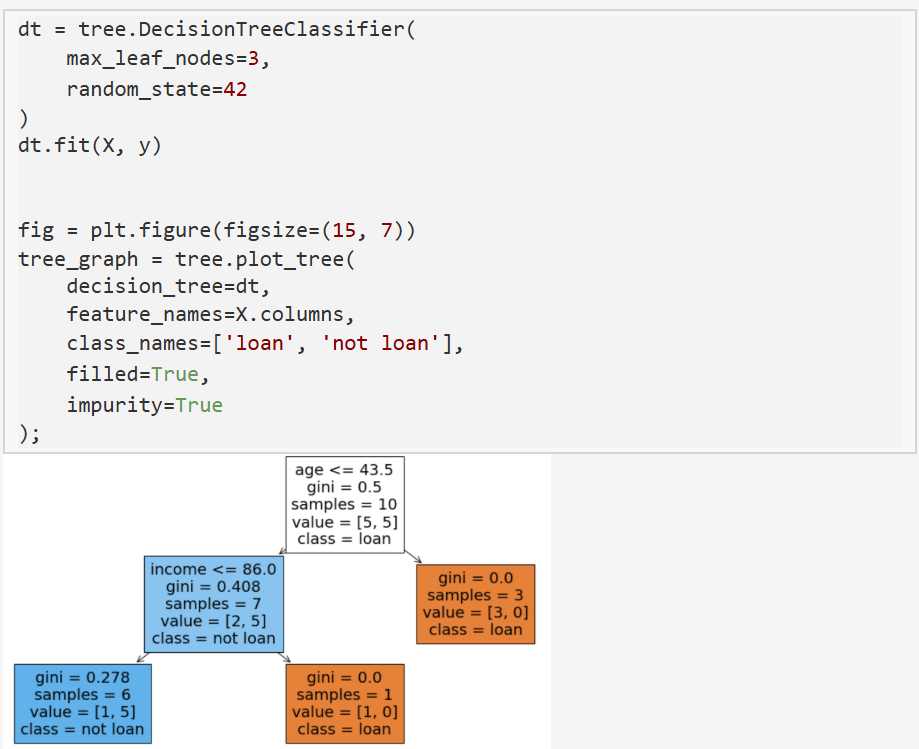

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Видим, что из-за ограничения на количество листьев в дереве разделения по предикату  не произошло — вместо этого данная вершина превратилась в листовую, и итоговая глубина дерева уменьшилось с 4 до 3. Общее количество листьев в дереве, как мы и указывали, равно 3.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>4</strong></span><b>Ограничение на минимальное количество объектов, при которых допускается ветвление дерева (параметр min_samples_split)</b>

Идея ограничения проста, как и все предыдущие. Пусть в вершину попала выборка $Q_v$, количество объектов в этой вершине — $N_v=5$. При этом однородность в этой вершине не равна 0.

По идее, ветвление дерева должно быть продолжено. Однако если мы установим ограничение на минимальное количество объектов для разделения *(min_samples_split = 6)*, то разделения вершины не произойдёт.

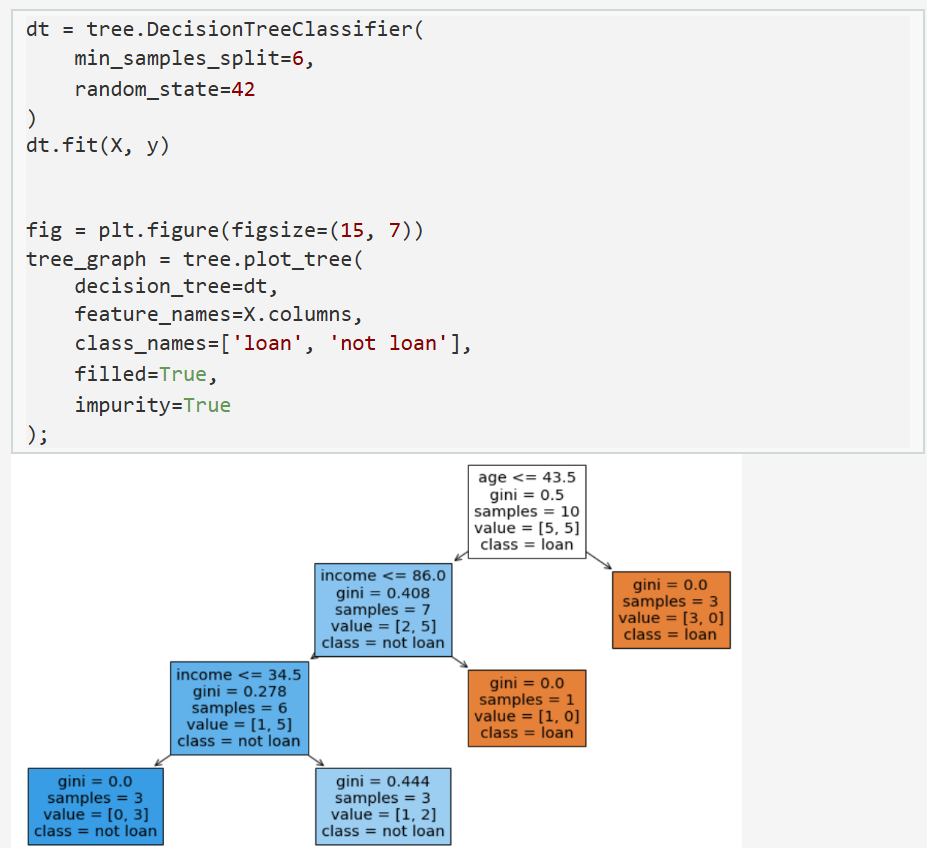

Видим, что разделение по условию $income \le 34.5$ произошло, так как количество объектов в вершине (samples), соответствующей ему, равно 6. А вот в вершинах, где количество наблюдений равно 3, разделения не произошло.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>5</strong></span><b>Ограничение на минимальное количество объектов, необходимых для создания листа (параметр min_samples_leaf)</b>

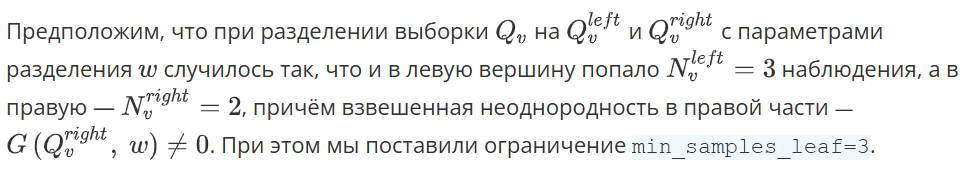

В таком случае, даже несмотря на неравенство нулю неоднородности в правой вершине, ветвления не произойдёт, так как минимальное количество объектов, которое допускается в листовой вершине, — 3. Это значит, что разделение вершины на две новых при таких параметрах разделения не будет произведено.

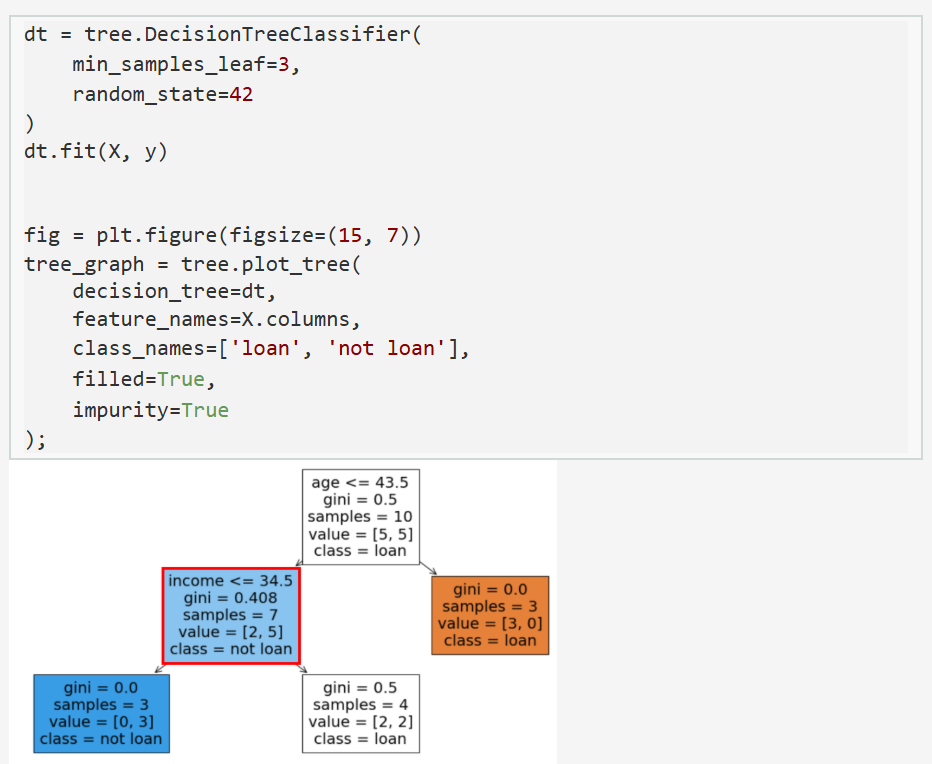

Обратите внимание, что в выделенной $\color{red}{\text{красным}}$ вершине ранее находилось условие $income \le 86$, а теперь там находится условие $income \le 34.5$. Как это произошло?

На самом деле всё просто. При разделении по решающему правилу $[income \le 86]$ у нас бы получались две новых вершины: в левой находилось бы шесть объектов, а в правой — один, причём правая вершина стала бы листовой. Однако у нас стоит ограничение: количество объектов в листовых вершин должно быть не менее 3. Поэтому такое разделение нам не подходит. Под данное условие подходит только одно решающее правило — $[income \le 34.5]$. При таком разделении в левую вершину попадает три объекта, а в правую — четыре. После этого ветвление прекращается.

Давайте адаптируем наш метод построения дерева решений и введём новое ограничение на максимальную глубину дерева: в функции *stop_criterion()* и *build_decision_tree()* добавим параметр *max_depth*, а также счётчик глубины рекурсии *depth*<br>
(**См. MATH&ML\Примеры решения\MATH&ML-8_DecisionTree_CART\Алгоритм CART: рекурсия, критерии остановки**):

In [ ]:
def stopping_criterion(X, y, criterion, max_depth=None, depth=0):
    if max_depth is None:
        return (criterion(y) == 0) 
    else:
        return (criterion(y) == 0) or (depth > max_depth)
    
def build_decision_tree(X, y, criterion, max_depth=None, depth=0):
    depth += 1
    if stopping_criterion(X, y, criterion, max_depth, depth):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion=entropy)
        X_left, y_left, X_right, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion, max_depth, depth)
        right = build_decision_tree(X_right, y_right, criterion, max_depth, depth)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    return node

Чтобы проверить результат, построим дерево с максимальной глубиной 2. В качестве данных используем данные о кредитах:

In [ ]:
# Строим дерево решений с ограничением глубины и выводим его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy, max_depth=2)
print_decision_tree(decision_tree)

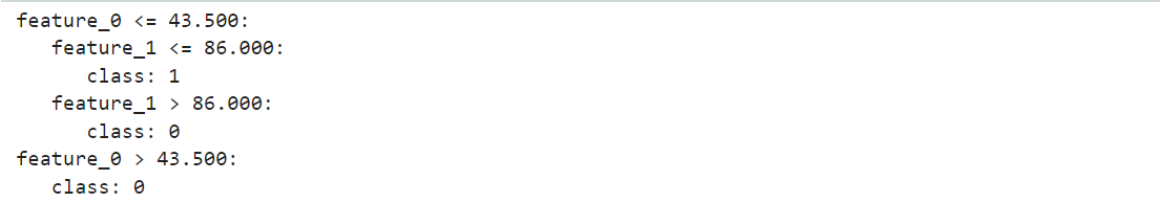

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">→ Как вы уже знаете, можно использовать одновременно несколько критериев остановки, тем самым управляя сложностью модели. Например, вы можете одновременно ограничивать и максимальную глубину (max_depth) и количество объектов, необходимых для разделения (min_samples_split). Однако, нельзя заранее сказать, какие внешние параметры дерева решений подойдут вам для решения конкретной задачи, поэтому используются знакомые вам методы подбора гиперпараметров, которые мы обсуждали в модуле <b>ML-7. «Оптимизация гиперпараметров модели»</b>.

## 6. Алгоритм CART: значимость признаков

Мы знаем, что при построении деревьев рассчитывается так называемая **информативность**, или **важность каждого признака** из обучающего набора данных. Эта величина численно отражает, насколько значимым был фактор $x_j$ для обучения модели, как много информации он даёт.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Как рассчитать эту величину?

На самом деле всё довольно просто, все компоненты этой задачи у нас уже есть.

Для начала вспомним, что такое **прирост информации (information gain)**. Это разница между неоднородностью в вершине $v$ до её деления и взвешенной неоднородностью после деления по предикату $B_v(x_j,\ t)=[x_j \le t]$ 

$$IG(Q_v,\ w)=H(Q_v)-G(Q_v,\ w)=H(Q_v)-\ \frac{N^{left}_v}{{N_v}}H(Q^{left}_v)-\frac{N^{right}_v}{N_v}H(Q^{right}_v)$$

Иначе говоря, это численное отражение того, сколько информации о целевой переменной нам дал фактор $x_j$ после разделения вершины.

Смысл формулы не изменится, если умножить всё выражение на $N_v$, а вот вид она примет более приятный:

$$IG(Q_v,\ w)={N_v}\cdot H(Q_v)-\ N^{left}_v\cdot H(Q^{left}_v)-N^{right}_v\cdot H(Q^{right}_v)$$

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Так как выражение для прироста информации — это не уравнение, то умножать левую часть на $N_v$ необязательно, так как мы просто переходим от одного масштаба к другому.<br>
Значения прироста информации $IG(Q_v, w)$, вычисленные по первой и второй формулам выше, будут различаться ровно в $N_v$ раз, однако при дальнейших вычислениях это не будет иметь значения. Нам не важно, в чём измерять прирост информации (в единицах или сотнях), так как это абстрактная величина.

<span style="display: inline-block; text-align:center;  line-height: 30px;  font-size: 16px;color: #2e765e; width: 30px; height: 30px; border: 2px solid #2e765e; border-radius: 50%; margin: 0px 20px 20px;"><strong>?</strong></span>Итак, $IG(Q_v,\ w)$ — это прирост информации, который даёт признак $x_j$ в вершине с номером $v$. А что, если вершин, которые используют признак $x_j$, будет несколько?

Тогда мы возьмём все эти вершины, посчитаем в них суммарную информативность, а затем разделим сумму на изначальное количество объектов в датасете. В итоге мы получим суммарный прирост информации, получаемый деревом от фактора $x_j$, на один объект из обучающей выборки. Эту величину как раз и назовём <b>(абсолютной) значимостью признака $x_j$</b> :

$$F(x_j)=\frac{1}{n}\sum_{v\ \in \ V_j}{}IG(Q_v,\ w)$$

Здесь запись $\sum_{v\ \in \ V_j}$ означает, что мы суммируем прирост информации по тем вершинам, которые содержат признак $x_J$ внутри условия предиката.

В результате по введённой формуле мы можем подсчитать значимость для каждого признака $x_j$ из обучающей выборки — получим целый список из  таких чисел:

$$F(x_1),F(x_2),...,\ F(x_M)\$$

Последний шаг — нормировка. Она производится для того, чтобы сумма всех значимостей была равна 1. Результатом будет относительная значимость признаков, которая позволяет воспринимать значение значимости каждого из признаков как выраженный в долях вклад фактора $x_j$ в построение дерева решений. 

Чтобы произвести нормировку, необходимо разделить каждое из значений информативности на общую сумму — получим относительные значимости:

$$\overline{F}(x_j)=\frac{F(x_j)}{\sum^M_{j\ =1}{}F(x_j)}$$

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Обратите внимание, что в данном выражении верхняя черта обозначает нормировку, а не усреднение.

Легко убедиться, что, просуммировав все нормированные значения информативности, мы получим 1:

$$\sum^M_{j\ =1}{}\bar{F}(x_j)=1$$

Продолжим рассматривать датасет о выплатах кредитов банку. Напомним, что за $x_1$ мы обозначали возраст клиента (*age*), а за $x_2$ — его доход (*income*). Пусть мы обучили на данных модель дерева решений и получили следующий граф:

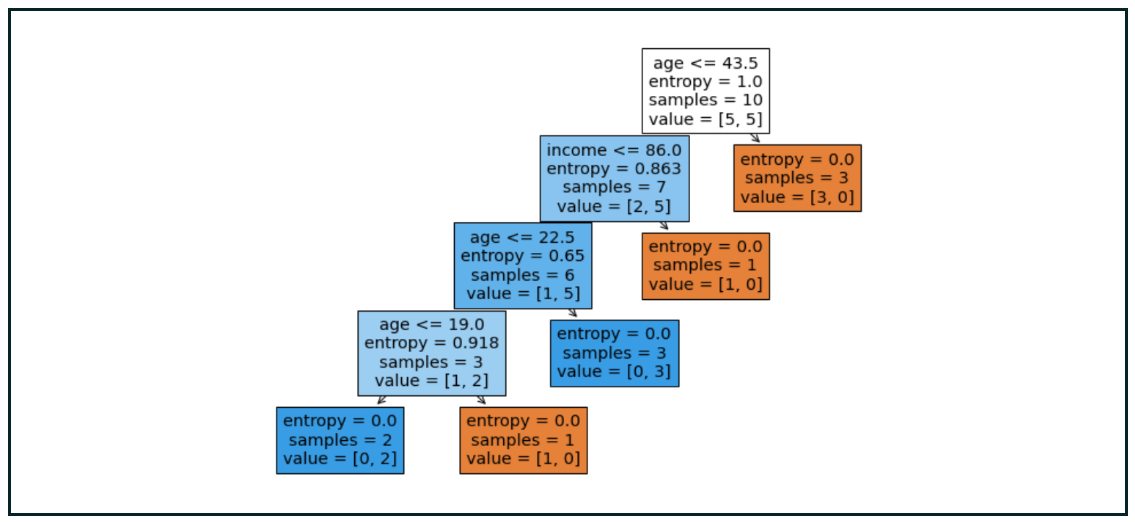

Давайте рассчитаем относительную значимость каждого из признаков — $\overline{F}(x_1)$ и $\overline{F}(x_2)$.

Сразу условимся, что корневую вершину будем нумеровать как $v=0$, а остальные — в формате $v=ij$, где $i$ — глубина, на которой находится вершина, а $j$ — порядковый номер слева направо, начиная с 1.

Начнём с признака возраста — $x_1$. На графе ниже выделены вершины, в которых содержится данный фактор.

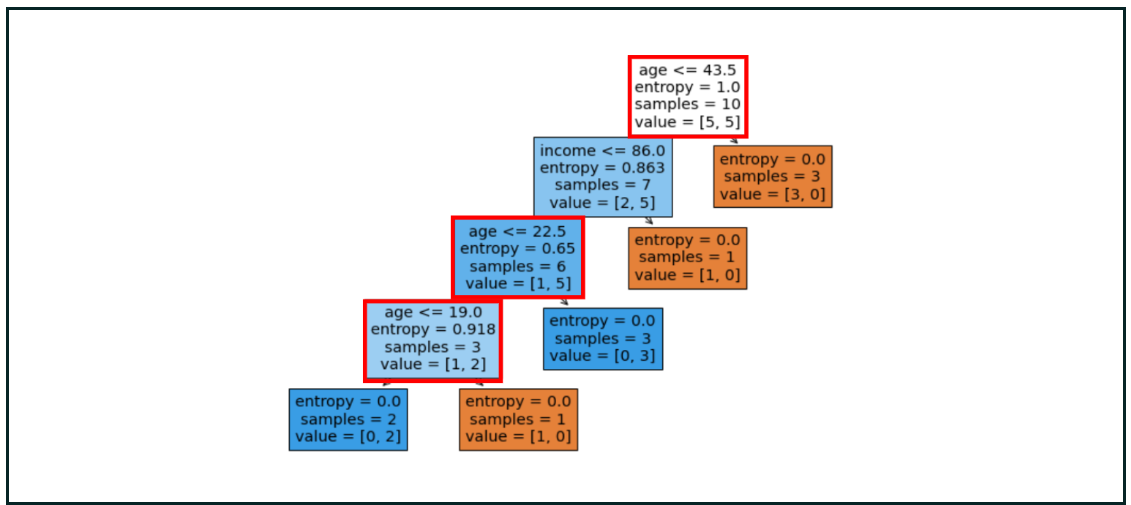

Считаем прирост информации для $x_1$ в корневой вершине. Все данные для этого у нас есть. Размеры выборок $N_v$ записаны в поле *samples*, а значения неоднородности вершины $H(Q_v)$ (в данном дереве используется энтропия) записаны в поле *entropy* — нам нужно только подставить числа в формулу:

$$IG(Q_0,\ w)={N_0}\cdot H(Q_0)-\ N^{left}_0\cdot H(Q^{left}_0)-N^{right}_0\cdot H(Q^{right}_0)=$$ $$=10\cdot 1-\ 7\cdot 0.863-3\cdot 0=3.958$$

Считаем прирост информации в вершине $v=21$:

$$IG(Q_{21},\ w)=6\cdot 0.65-\ 3\cdot 0.918-3\cdot 0=1.146$$

Считаем прирост информации в вершине $v=31$:

$$IG(Q_{31},\ w)=3\cdot 0.918-\ 2\cdot 0-1\cdot 0=2.754$$

Считаем абсолютную значимость признака $x_1$ — прирост информации на одно наблюдение:

$$F(x_1)=\frac{1}{N}\sum_{v\ \in \ \{v_0,v_{21},\ v_{31}\}\ }{}IG(Q_v,\ w)=\frac{1}{10}(3.958+1.146+2.754)=0.786$$

Переходим к признаку дохода — $x_2$. На графе ниже выделены вершины, в которых содержится данный фактор.

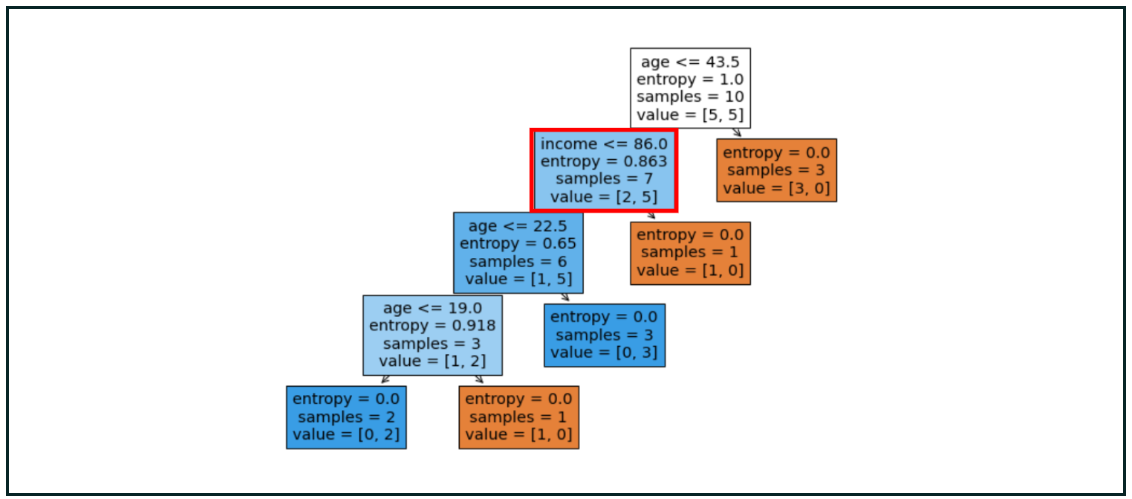

Считаем прирост информации для $x_2$ в вершине $v=11$: 

$$IG(Q_{11},\ w)=7\cdot 0.863-\ 6\cdot 0.65-1\cdot 0=2.142$$

Считаем абсолютную значимость признака $x_2$ — прирост информации на одно наблюдение:

$$F(x_2)=\frac{1}{N}\sum_{v\ \in \ \{v_{11}\}\ }{}IG(Q_v,\ w)=\frac{1}{10}\cdot 2.141=0.214$$

Финальный шаг — нормировка. Вычислим относительные значимости признаков $x_1$ и $x_2$ и разделим абсолютные значимости на их сумму:

$$\overline{F}(x_1)=\frac{F(x_1)}{\sum^2_{j\ =1}{}F(x_j)}=\frac{0.786}{0.786+0.214}=0.786$$

$$\overline{F}(x_2)=\frac{F(x_1)}{\sum^2_{j\ =1}{}F(x_j)}=\frac{0.214}{0.786+0.214}=0.214$$

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px">Обратите внимание, что для случая двух факторов абсолютная и относительные значимости будут всегда совпадать.

Интерпретировать полученные результаты можно следующим образом: доля информации, которую принёс признак возраста клиента $x_1$ при построении дерева решений для целевой переменной y (класса объекта — факта выплаты кредита заёмщиком), составляет 0.786, или 78.6%. Признак заработка $x_2$ дал дереву 21.4% информации о целевой переменной.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Здесь нужно сделать важное замечание. Обратите внимание, что полученные результаты относятся к конкретному дереву решений, представленному на графе выше. Полученный результат вовсе не означает, что возраст клиента важнее его заработка при принятии решения о выдаче кредита в глобальном смысле. Принимая какую-то гипотезу и делая категоричные выводы на подобных маленьких выборках с использованием только одного дерева решений, вы рискуете допустить серьёзную исследовательскую ошибку.<br>
Более корректные результаты можно получить на выборках больших размеров с использованием не одного дерева решений, а целых ансамблей из деревьев (случайный лес или градиентный бустинг, о которых мы поговорим в следующем модуле).

 Финальный этап — перевод математики в код ↓

#### См. MATH&ML\Примеры решения\MATH&ML-8_DecisionTree_CART\Алгоритм CART: значимость признаков

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Если факторов, участвующих в построении дерева, много, то удобнее всего отсортировать их по коэффициенту значимости и визуализировать, например, в виде столбчатой диаграммы значимости. Пример:

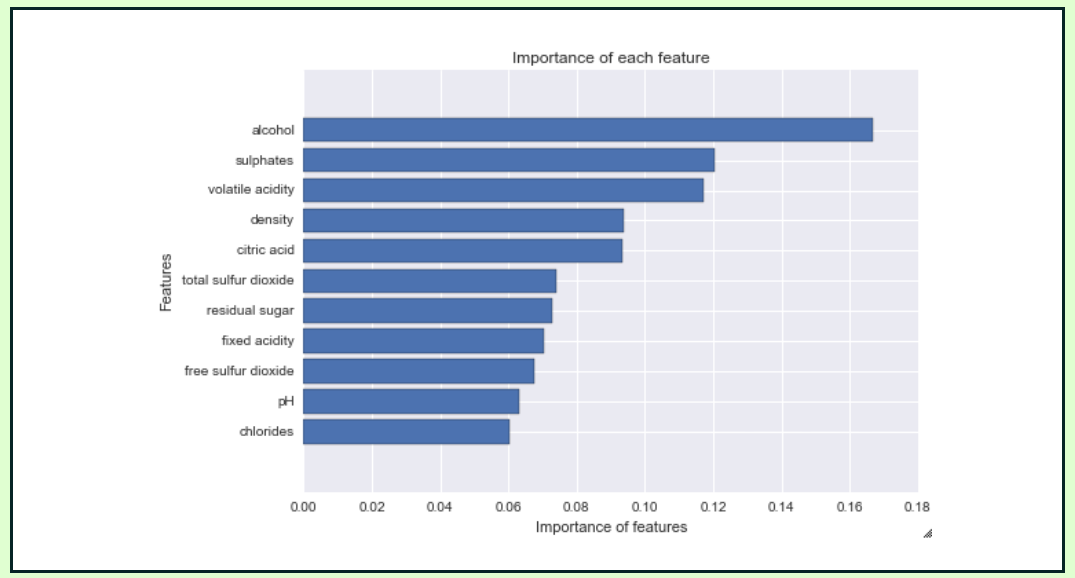

## 7. Деревья решений: практика

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Начнём немного издалека. Представьте, что вы общаетесь с незнакомым человеком по телефону или сидя к нему спиной. Сможете ли вы по нескольким фразам понять, какого пола ваш собеседник? В большинстве случаев это будет лёгкой задачей. Но задумывались ли вы, как ваш мозг определяет пол человека по голосу?

Всё очень просто: женские и мужские голоса заметно различаются по акустическим свойствам. Есть существенные физиологические различия, подтверждённые научно и активно используемые как в общественной жизни, так и технических устройствах. Они обусловлены небольшими различиями в строении речевого аппарата мужчины и женщины, которые формируются с возрастом. Эти различия проявляются в частотах звука, тембре и громкости.

<p style="border:3px aquamarine solid; text-align: left; padding: 10px">Почему бы нам не обучить модель машинного обучения классифицировать людей на мужчин и женщин по их голосу? Системе идентификации пола по голосу, основанной на такой модели, можно найти применение во многих областях — от маркетинга до интегрирования в системы безопасности.

Мы пока что не умеем работать с аудиоинформацией и преобразовывать её в привычный нам формат табличных данных, поэтому для решения данной задачи мы нашли готовый датасет, в котором все преобразования аудиоинформации в числовой табличный формат уже произведены.

Оригинальную страницу датасета на Kaggle с подробным описанием задачи вы можете найти [здесь](https://www.kaggle.com/datasets/primaryobjects/voicegender).

Набор данных состоит из 3 168 записанных образцов голоса мужчин и женщин. Образцы предварительно обрабатываются с помощью акустического анализа на языке программирования R с использованием специальных библиотек в диапазоне частот 0 Гц-280 Гц (диапазон человеческого голоса). Если вкратце, в результате обработки звук на аудиозаписи оцифровывается и преобразуется в числовую последовательность частот, из которой извлекаются различные статистические характеристики, например средняя частота, с которой говорит спикер на аудиозаписи, или частота с наибольшей энергией и так далее.

Файл с данными, представленными в формате CSV, вы можете скачать [здесь](https://lms-cdn.skillfactory.ru/assets/courseware/v1/0446d35f217801309147def00a120238/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block/voice_gender.zip).

В столбцах таблицы содержатся статические характеристики для каждой из аудиозаписей, вычисленные на основе акустических свойств.

<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">
Очень часто Data Scientist сталкивается с задачами, которые находятся за гранью области его компетенций. Типичный пример — медицинские задачи. Дата-сайентист может не разбираться в том, как получаются те или иные медицинские показатели, в чём они измеряются и какая у них норма, ведь это зона компетенций врача. Однако это же не повод не решать поставленную задачу (хотя, конечно же, базовое понимание внутренней кухни в большинстве случаев даёт определённый бонус).<br>
Мы сейчас как раз рассматриваем пример подобного рода — нам интересен не столько процесс извлечения данных из каждой аудиозаписи, сколько сам результат.<br>
Наша цель как специалистов в Data Science состоит в построении модели распознавания пола по уже обработанным аудиозаписям, а не в проектировании процесса их обработки. То есть в процессе решения задачи вы вполне можете абстрагироваться от непосредственного значения самих признаков и воспринимать их в математическом ключе как векторы $x_1, \ x_2, \ ..., \ x_M$.

## См. MATH&ML_Practice\MATH&ML-8. Алгоритмы на основе деревьев решений\Деревья решений: практика

Резюмируя, приведём основные **преимущества и недостатки деревьев**:

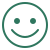
- Алгоритм способен решать как задачи классификации, так и задачи регрессии

- Простой для понимания и интерпретируемый алгоритм, понятный даже людям, не знакомым с машинным обучением. Можно визуализировать в виде графа.

- Не требуется нормализация/стандартизация данных.

- В общем случае деревья могут обрабатывать как числовые, так и категориальные данные. Однако в sklearn категориальные признаки, представленные в нечисловом формате, не поддерживаются.

- Дерево способно решать задачи с несколькими выходами, то есть когда целевая переменная имеет размерность больше 1.

- На основе значимости признаков можно производить их отбор. Однако коэффициенты значимости напрямую зависят от сложности дерева.

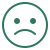

- В силу дискретной топологической структуры дерево не дифференцируется по параметрам — стандартные алгоритмы поиска параметров, такие как градиентный спуск, не работают. Приходится использовать полный перебор, что значительно увеличивает время построения модели, особенно для выборок больших размеров.

- Чрезвычайно сильная склонность к переобучению. Необходим подбор внешних параметров, таких как максимальная глубина, минимальное количество объектов для разделения вершины и других.

- Деревья решений могут быть нестабильными: небольшое изменение в данных способно заметно повлиять на структуру дерева.

- Функция дерева является кусочно-постоянной, поэтому деревья не могут использоваться для экстраполяции (предсказания целевой переменной за границами обучающей выборки).

- Поиск оптимального по структуре дерева решений является NP-полной задачей. Следовательно, практическая реализация дерева решений основана на эвристиках, таких как жадный алгоритм. Он, в свою очередь, не гарантирует того, что дерево будет самым оптимальным.

- Дерево может плохо справляться с несбалансированными данными.

Как вы уже знаете, от многих из представленных недостатков деревьев можно избавиться, если объединить несколько деревьев в ансамбли. В следующем модуле мы как раз поговорим о математической формализации ансамблевых методов.

Предлагаем вам познакомиться с **дополнительными материалами** по деревьям:

- [Лекция о деревьях решений от ВШЭ](https://www.hse.ru/mirror/pubs/share/215285956)

- [Статья о применении Cost Complexity Pruning](https://medium.com/analytics-vidhya/cost-complexity-pruning-in-decision-trees-f82b14a7fe91) — метода регуляризации деревьев решений путём их обрезки (в sklearn обрезка управляется параметром *ccp_alpha*)